# Two Hats: How Writing Behavior Relates to Evaluation Preference

Most models in this roster are both a **writer** (they generate cover letters) and an
**evaluator** (they score them). This notebook asks: for a given stylistic dimension, does
a model's own writing behavior line up with what it rewards as an evaluator? And across
the roster, do writers differ in what they lean on, and do evaluators differ in what they
reward?

**Methodology, in one paragraph:** for each pair of features, the *writer* panel plots
each model's average value of that feature minus the roster average (how much this writer
over/under-uses it, in raw units) — from `compute_writer_feature_deviation` /
`compute_echo_residuals` in `plot_model_explainability.py`. Valid without further
adjustment because every writer produces letters for the exact same 500 (job, CV) pairs
(a fully-crossed, balanced design), so job/candidate confounds cancel out of any
writer-to-writer comparison. The *evaluator* panel plots each model's Ridge regression
coefficient on that feature (`fit_regressions` in `plot_feature_regression.py`,
within-job demeaned, mutually adjusted for every other measured feature) — how much this
evaluator rewards or penalizes it, holding everything else fixed.

**Contents:**
1. Semantic fit: job ad vs. CV alignment
2. Language complexity: readability vs. word length (two angles)
3. Tone: dominance vs. arousal
4. Emotion: joy vs. neutral
5. The full picture, category by category
6. Key takeaways


In [1]:
import warnings; warnings.filterwarnings("ignore")
from IPython.display import Image, display
%matplotlib inline

CL_DIR = "output_plots/cl_features_no_gemini2"


---
## 1. Semantic Fit: Job Ad vs. CV Alignment


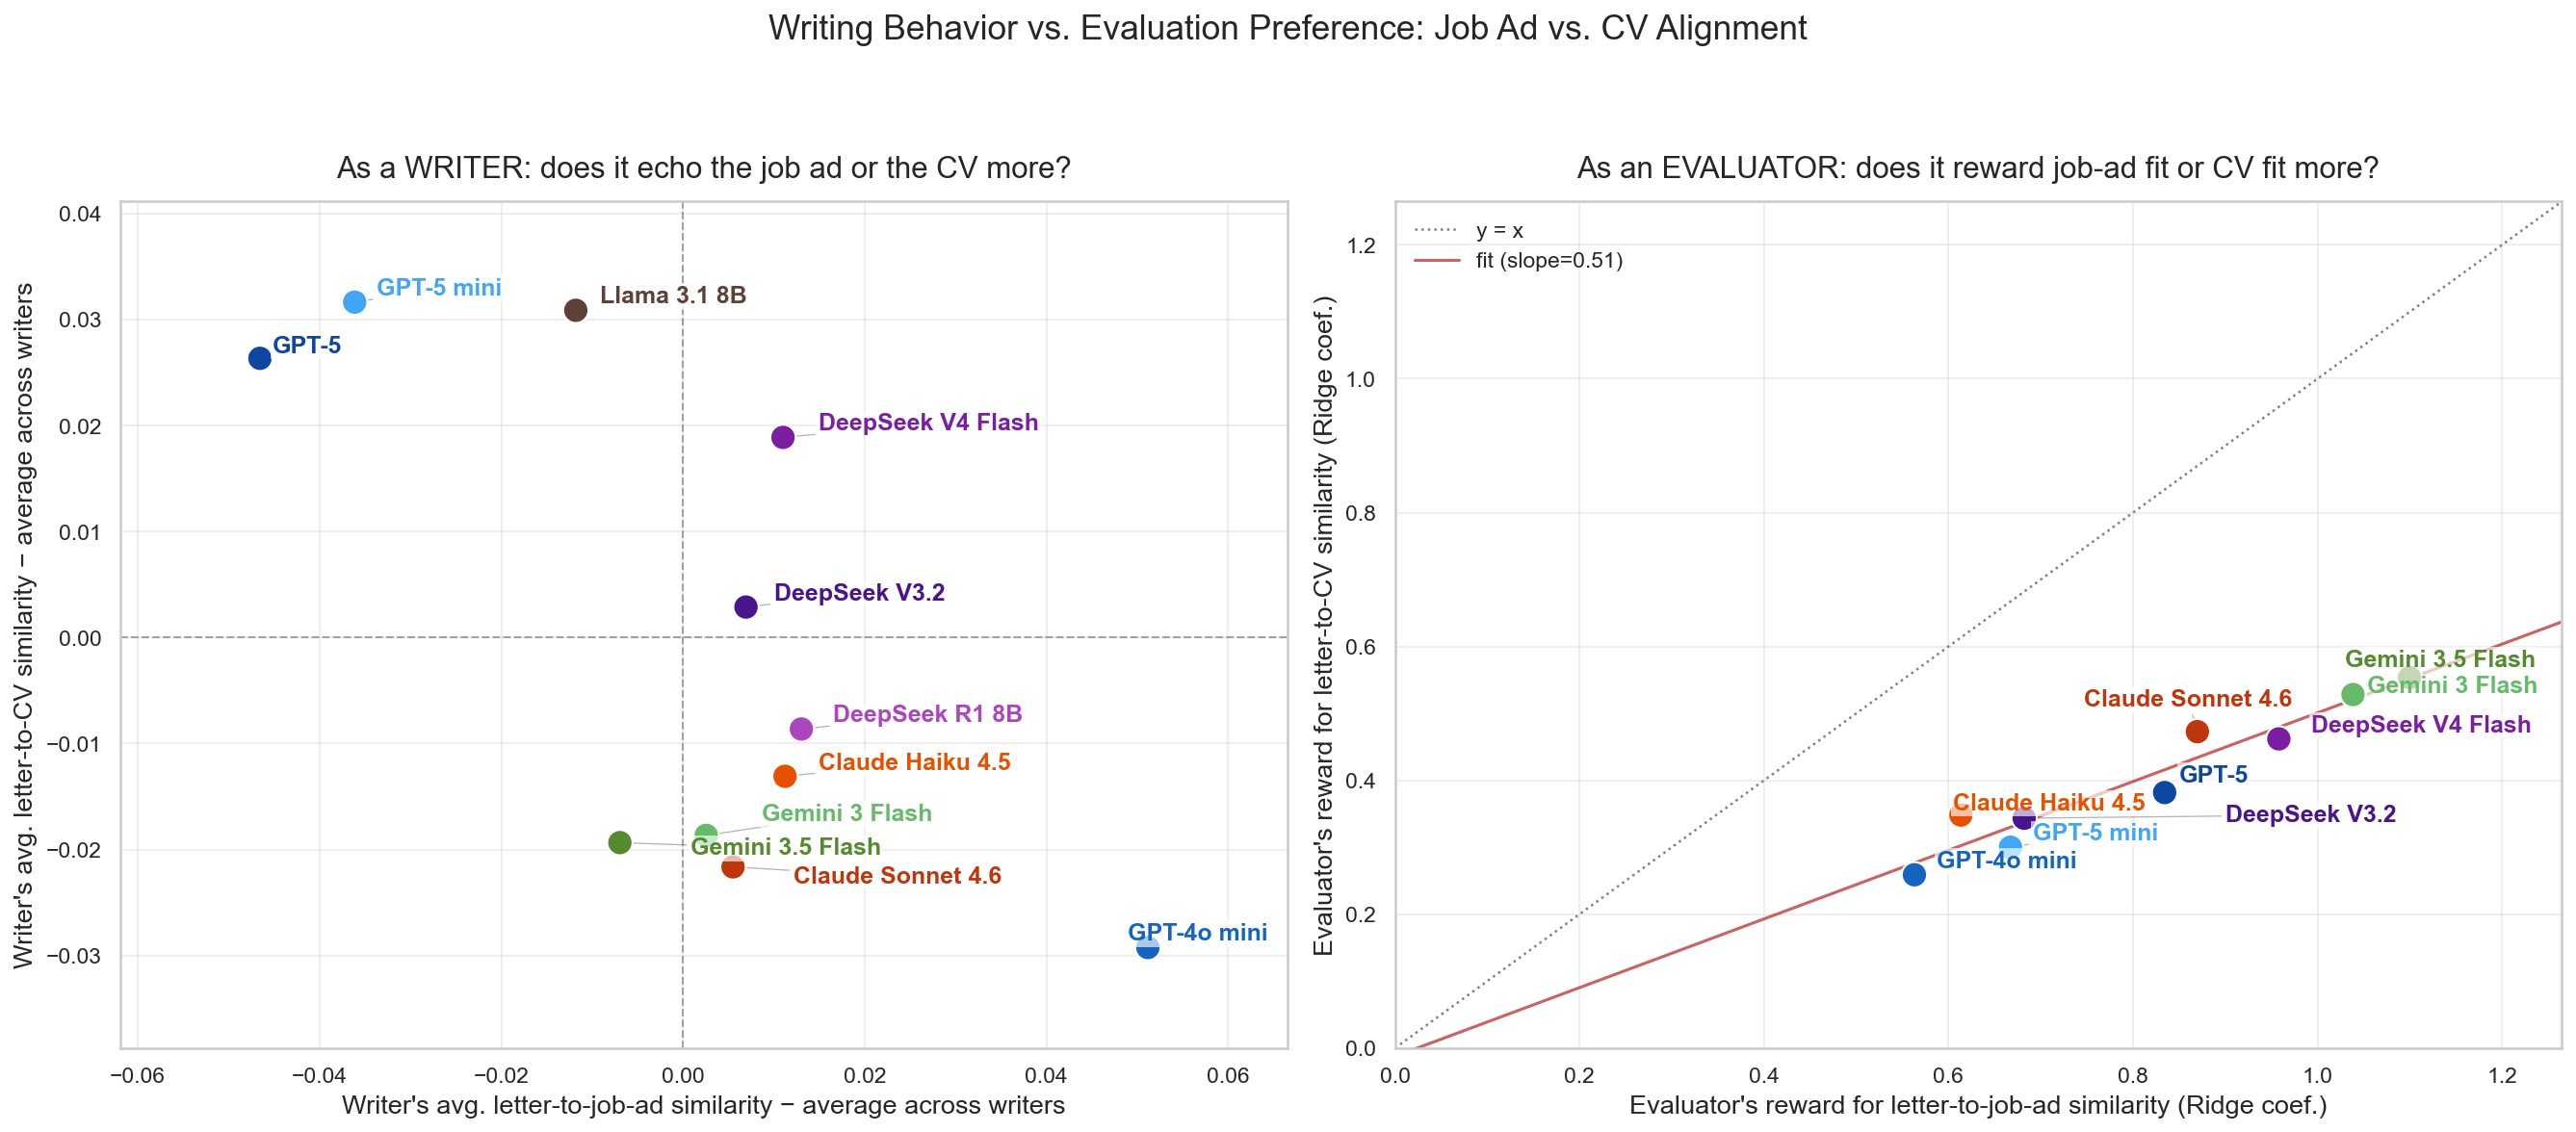

In [2]:
display(Image(f"{CL_DIR}/writer_vs_evaluator_cosine.png", width=1400))

**As writers** (left panel), models split into two camps: GPT-5, GPT-5 mini, and Llama
3.1 8B lean toward echoing the **job ad** and away from the CV; GPT-4o mini echoes the job
ad most of all *and* the CV least of all. Most other models sit closer to the origin,
mildly CV-leaning.

**As evaluators** (right panel), every single model rewards job-ad alignment more than CV
alignment — every point sits below the y = x line, and the fitted slope (0.51) says
job-ad fit is rewarded roughly twice as strongly on average. But there's real
heterogeneity in *how lopsided* that preference is: **GPT-4o mini and GPT-5 mini reward
job-ad fit almost exclusively**, while **Gemini 3 / 3.5 Flash, Claude Sonnet 4.6, and
DeepSeek V4 Flash are far more balanced**, valuing CV alignment nearly as much as job-ad
alignment.

Putting the two panels together: **GPT-4o mini's writing behavior and evaluation
preference are well aligned** (it echoes the job ad most and rewards job-ad fit most
exclusively). Others are less consistent — e.g. Gemini 3.5 Flash writes CV-leaning letters
but, as an evaluator, still rewards job-ad fit noticeably more than CV fit.


---
## 2. Language Complexity: Two Angles

### 2a. Readability vs. Word Length


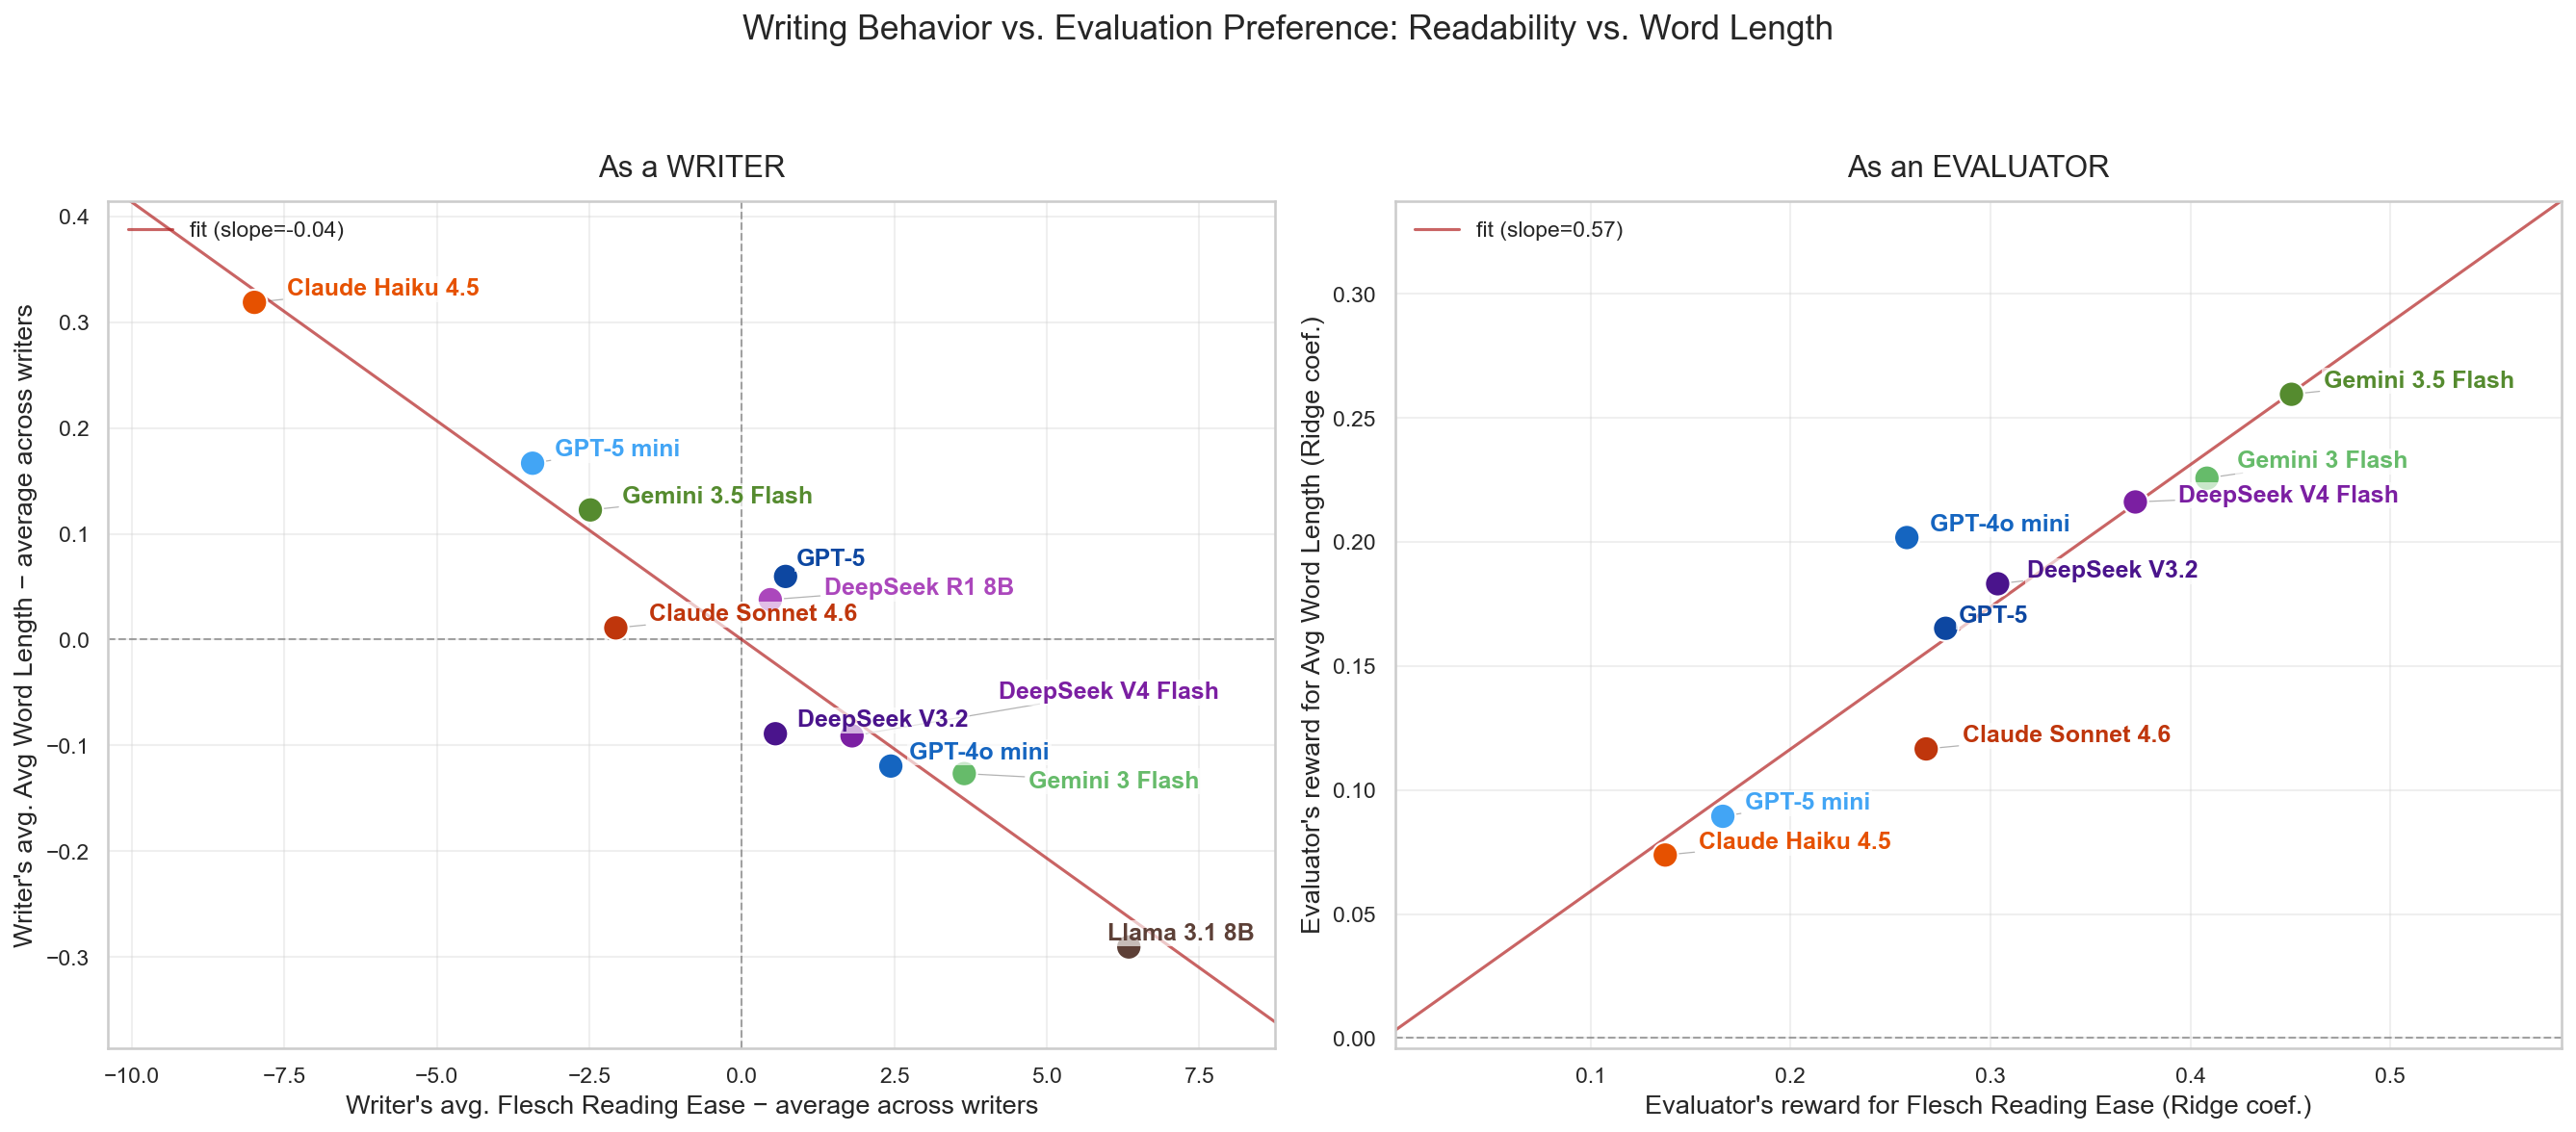

In [3]:
display(Image(f"{CL_DIR}/writer_vs_evaluator_flesch_wordlen.png", width=1400))

**As writers**, readability and word length trade off almost perfectly (slope -0.04 over a
wide range): models that write easy-to-read letters do so with **shorter** words (Llama
3.1 8B), and models that write harder-to-read letters use **longer** words (Claude Haiku
4.5). No writer in the roster combines short sentences/simple structure with long,
sophisticated vocabulary — the two pull in opposite directions.

**As evaluators**, that constraint disappears: every model rewards *both* higher
readability *and* longer average words simultaneously (slope +0.57, all points in the
positive/positive quadrant). Evaluators want a combination — readable structure with rich
vocabulary — that essentially no writer in the roster actually produces. GPT-4o mini
rewards word length most relative to readability; Gemini 3.5 Flash and Gemini 3 Flash
reward readability most.

### 2b. Length vs. Readability


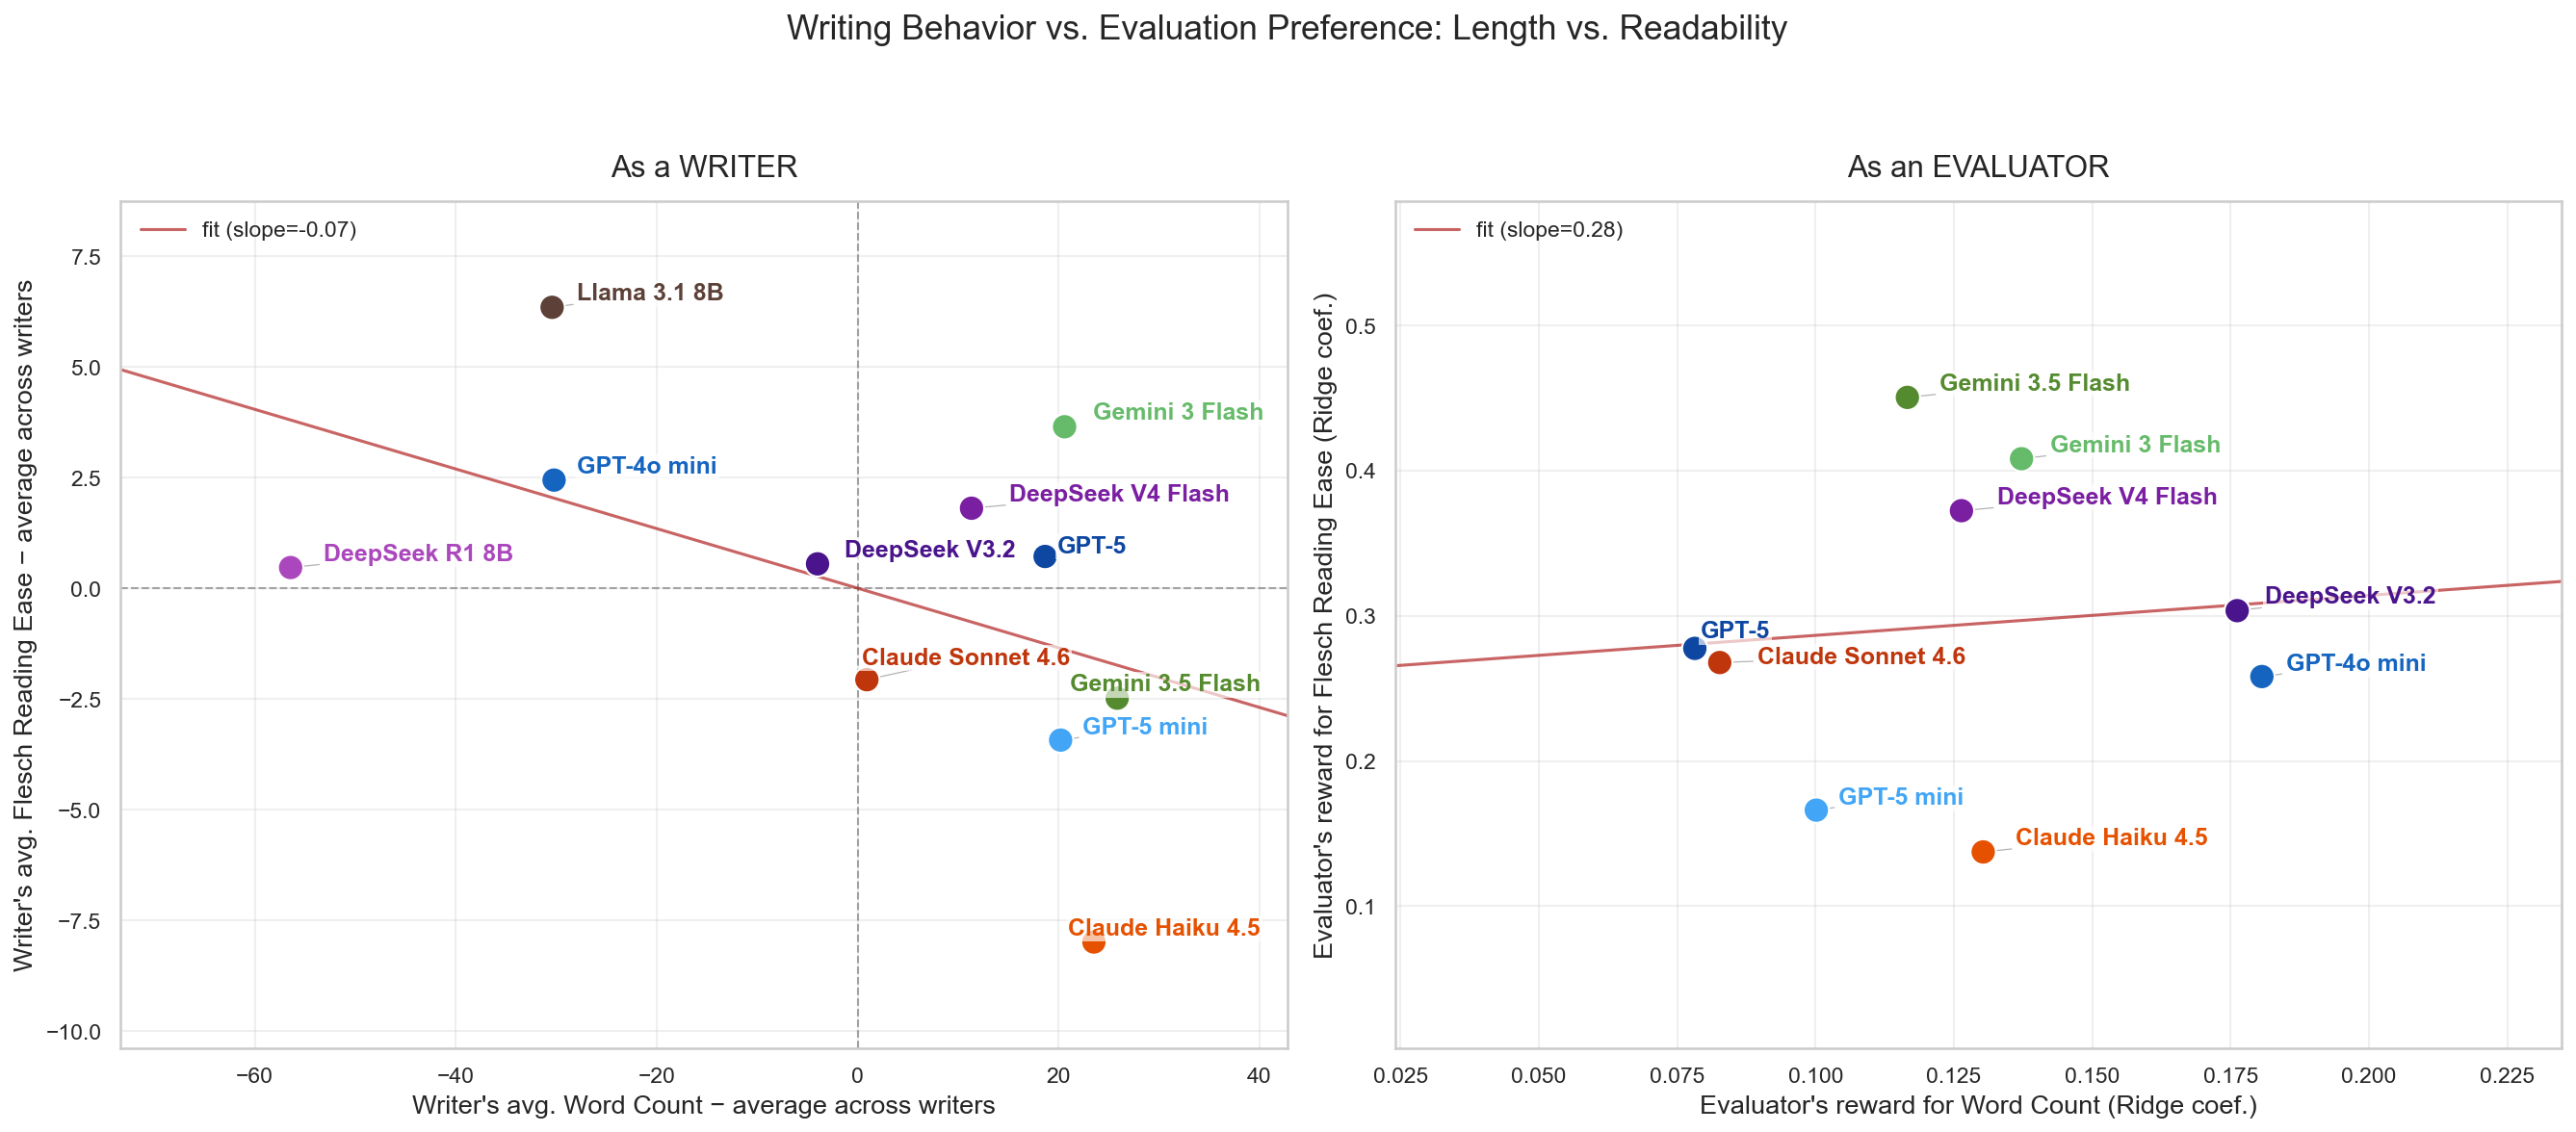

In [4]:
display(Image(f"{CL_DIR}/writer_vs_evaluator_wordcount_flesch.png", width=1400))

**As writers**, the more verbose models (Gemini 3 / 3.5 Flash, GPT-5 mini, Claude Haiku
4.5) tend to write measurably less readable letters; terser models (DeepSeek R1 8B, Llama
3.1 8B, GPT-4o mini) tend to be more readable. It's a real but noisier relationship than
the word-length trade-off above.

**As evaluators**, the relationship is close to flat (slope 0.28, much weaker than the
readability/word-length link) — rewarding word count doesn't strongly predict rewarding or
penalizing readability. Claude Haiku 4.5 and GPT-5 mini stand out as undervaluing
readability relative to the rest of the roster; GPT-4o mini overvalues word count relative
to how much it values readability.


---
## 3. Tone: Dominance vs. Arousal


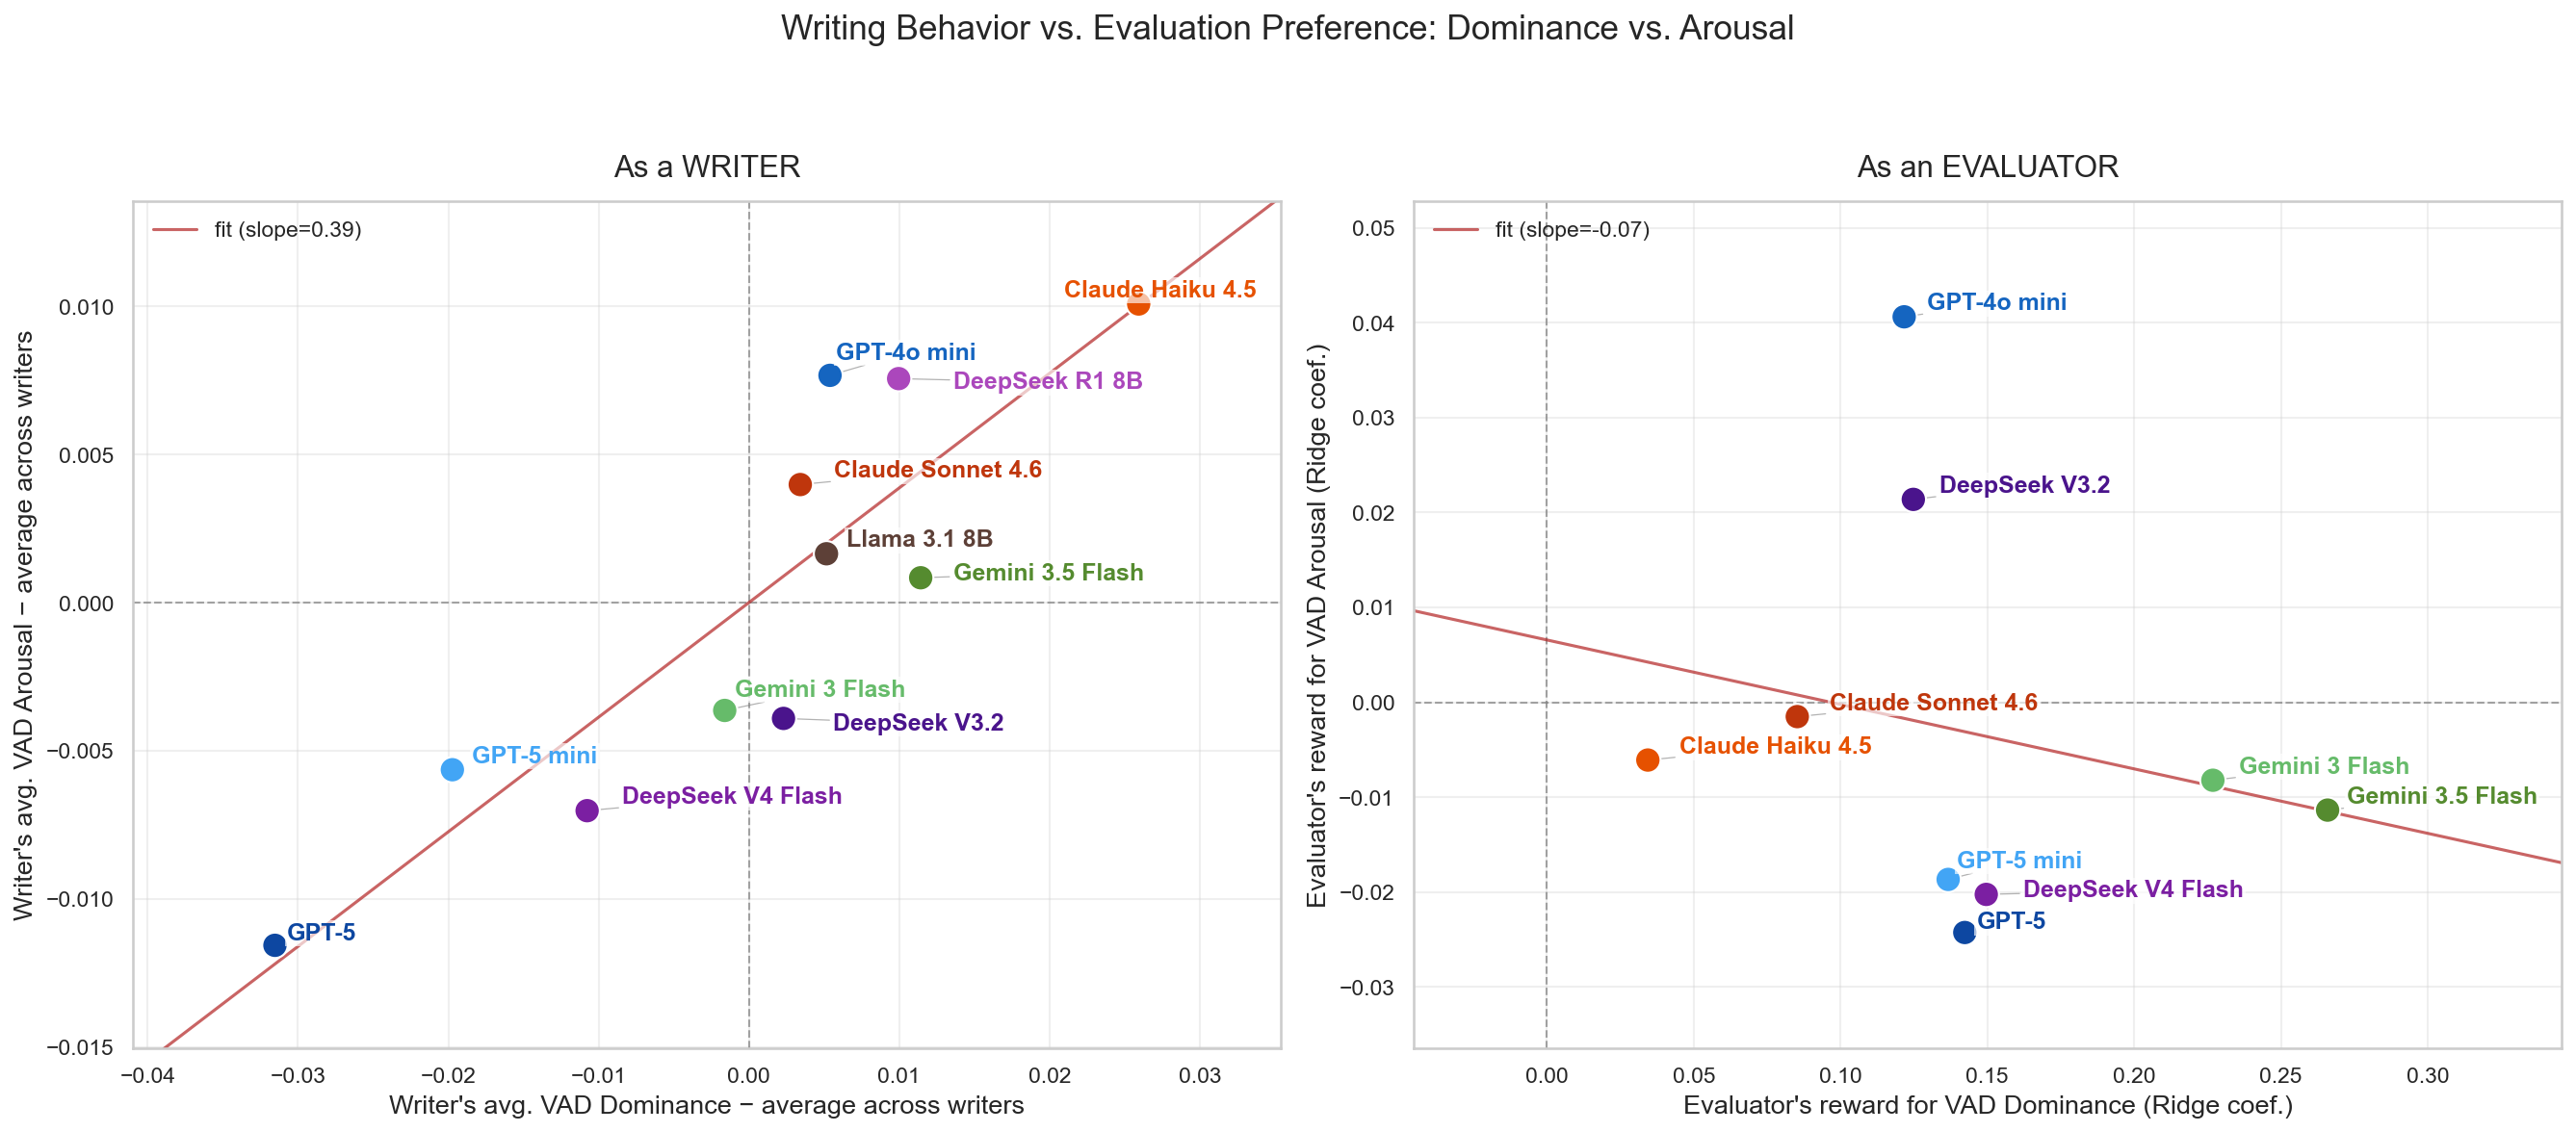

In [5]:
display(Image(f"{CL_DIR}/writer_vs_evaluator_dominance_arousal.png", width=1400))

**As writers**, dominance and arousal move *together* (slope +0.39): a more assertive,
confident-sounding letter (Claude Haiku 4.5, GPT-4o mini, DeepSeek R1 8B) also tends to
read as more energetic; a more restrained, hedging letter (GPT-5, GPT-5 mini) reads as
calmer too. It's one blended axis in practice, not two independent dimensions.

**As evaluators**, the relationship *reverses* (slope -0.07): every model rewards
dominance (all points sit at positive x), but the ones that reward it **most** (GPT-5,
DeepSeek V4 Flash) tend to reward arousal **least** — sometimes penalizing it. GPT-4o mini
is the outlier that rewards both together. In effect, most evaluators are looking for
"confident but composed" language — assertive without sounding keyed-up — a combination
that, again, cuts across how writers naturally produce the two together.


---
## 4. Emotion: Joy vs. Neutral Tone


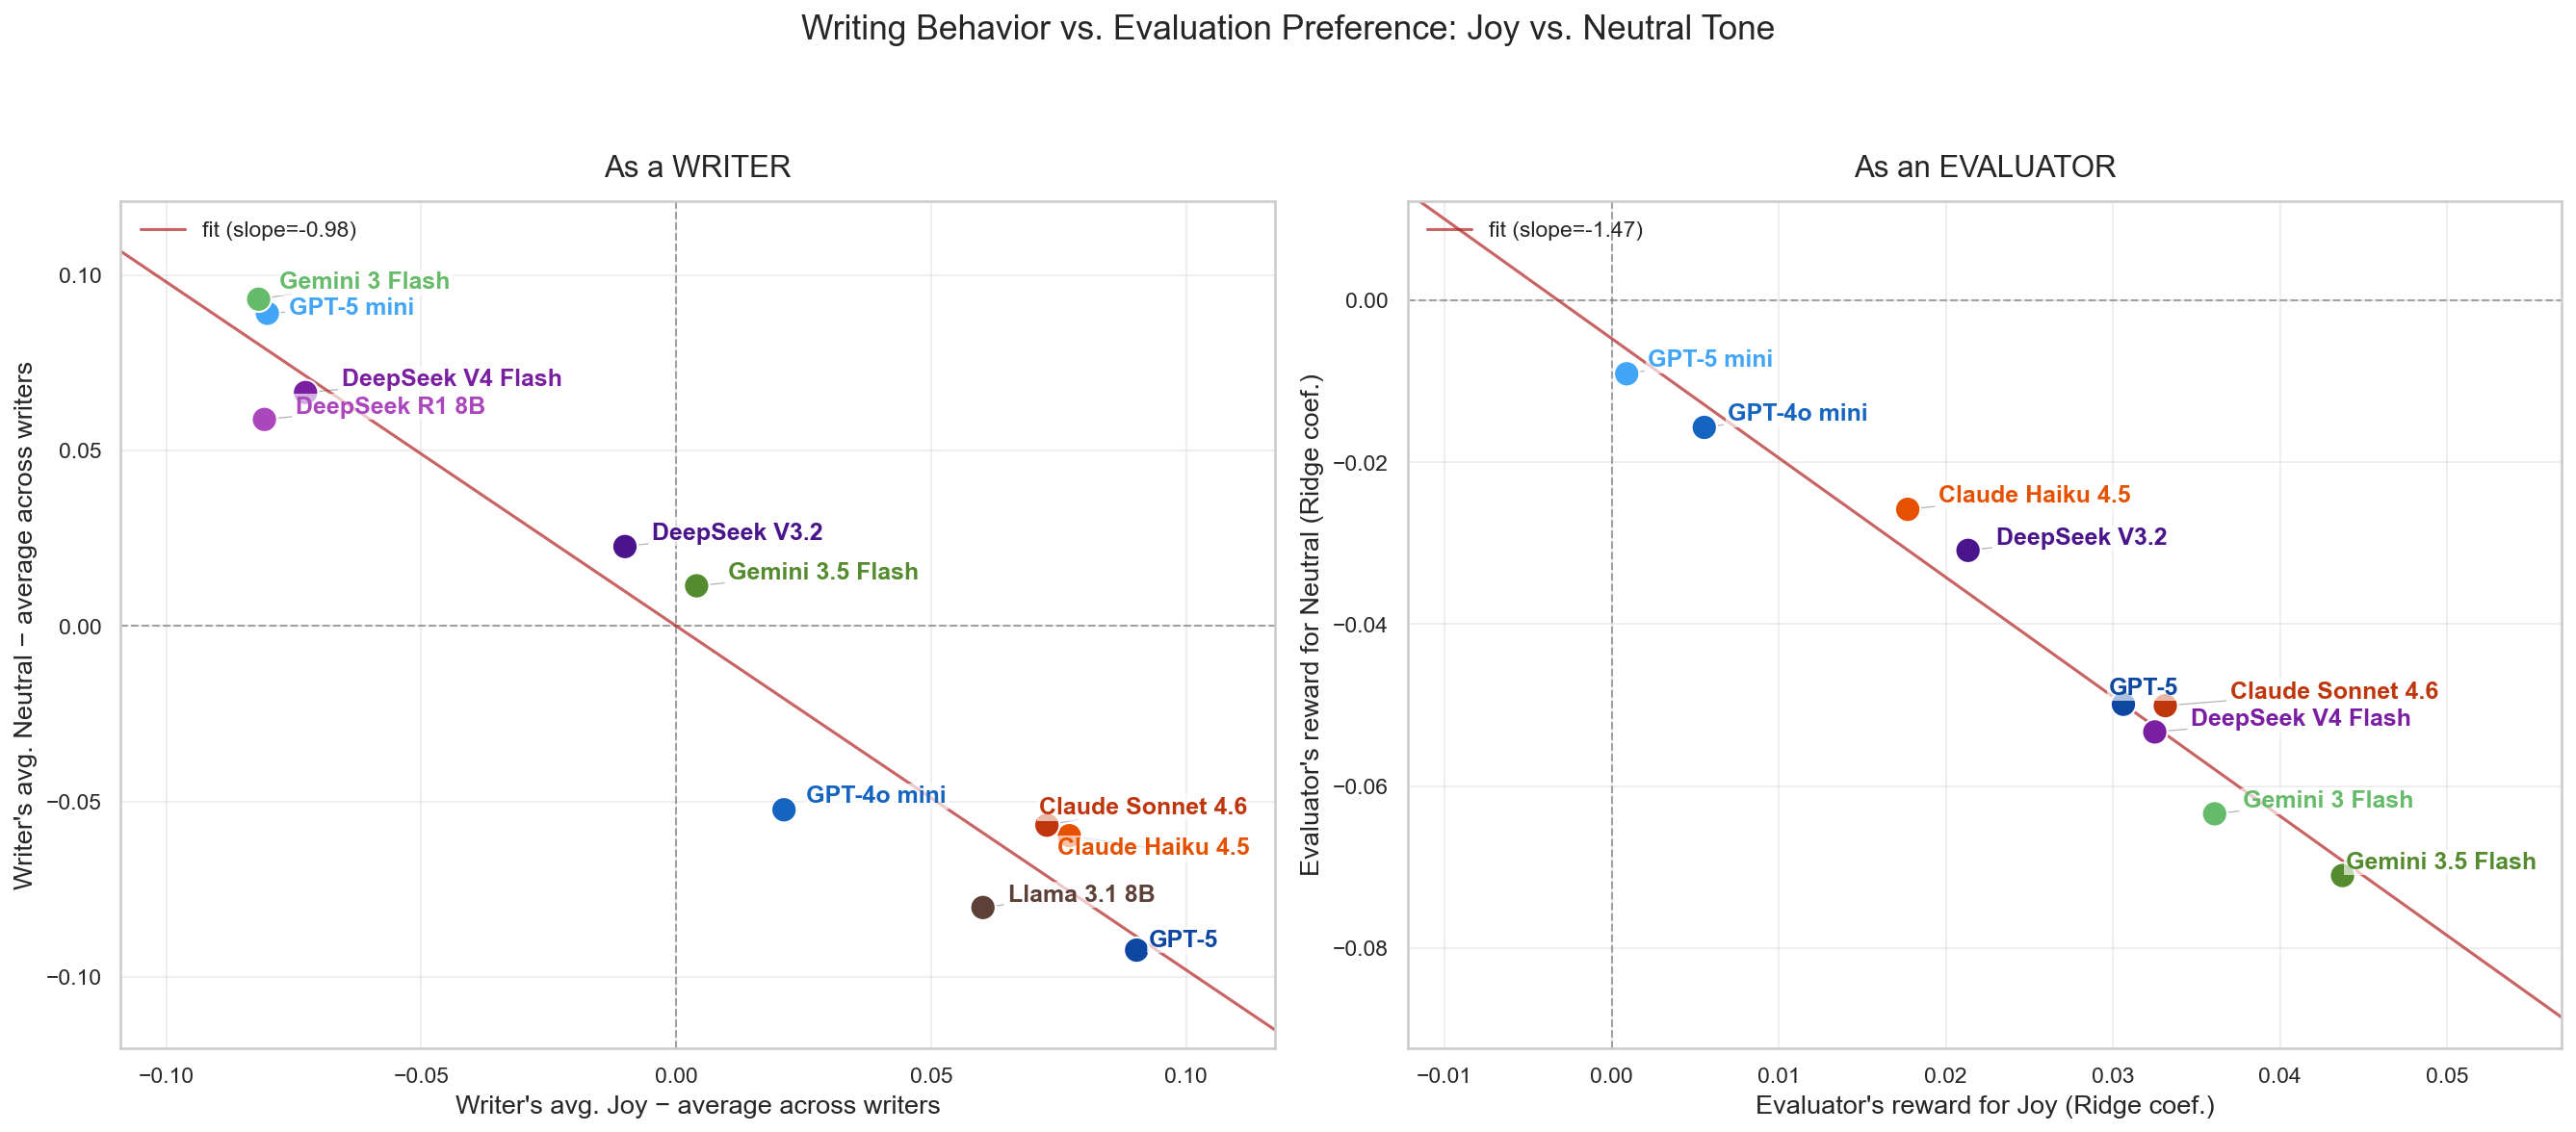

In [6]:
display(Image(f"{CL_DIR}/writer_vs_evaluator_joy_neutral.png", width=1400))

Both panels show a near-perfect trade-off (writers: slope -0.98; evaluators: slope -1.47).
Part of this is structural: joy and neutral are two of seven emotion probabilities that
must sum to 1 per letter, so a writer that scores higher on one will mechanically tend to
score lower on the other. But the **evaluator** panel isn't subject to that constraint —
Ridge coefficients on joy and neutral are fit independently — and it still shows an even
*steeper* mirror-image relationship. That's a genuine preference structure, not an
artifact: evaluators that reward warmth (Gemini 3.5 Flash, Gemini 3 Flash) penalize
neutral tone correspondingly hard, and vice versa (GPT-5 mini barely rewards joy and barely
penalizes neutral).


---
## 5. The Full Picture, Category by Category

> ## ⚠️ DATA SCOPE FOR ALL OF SECTION 5 ⚠️
> **Every figure in Section 5 (5a through 5f) uses the Cover-Letter-Only (`cl_evaluations`)
> condition exclusively.** None of it includes the CV + Cover Letter condition. This is a
> deliberate choice, not an oversight: Cover-Letter-Only isolates each evaluator's response
> to writing style alone, with no CV signal to confound it, which is what makes a
> self-preference/style-preference analysis interpretable in the first place. If a figure
> below doesn't say otherwise, assume "Cover-Letter-Only" applies to it.

The scatter plots above each isolate two features. These plots show **every writer x
every feature** in a category at once: each row is one (writer, feature) pair, with one
dot per evaluator showing its *signed* contribution to predicted preference (writer's
style x that evaluator's Ridge weight). **Self-evaluation dots are opaque; every other
evaluator's dot is faded**, so self-preference (or self-penalty) stands out at a glance.
The right-hand panel shows the actual raw-value distribution behind each row, one
independent x-axis per feature since units differ wildly within a category (e.g. word
count vs. comma count).

### 5a. Semantic Fit


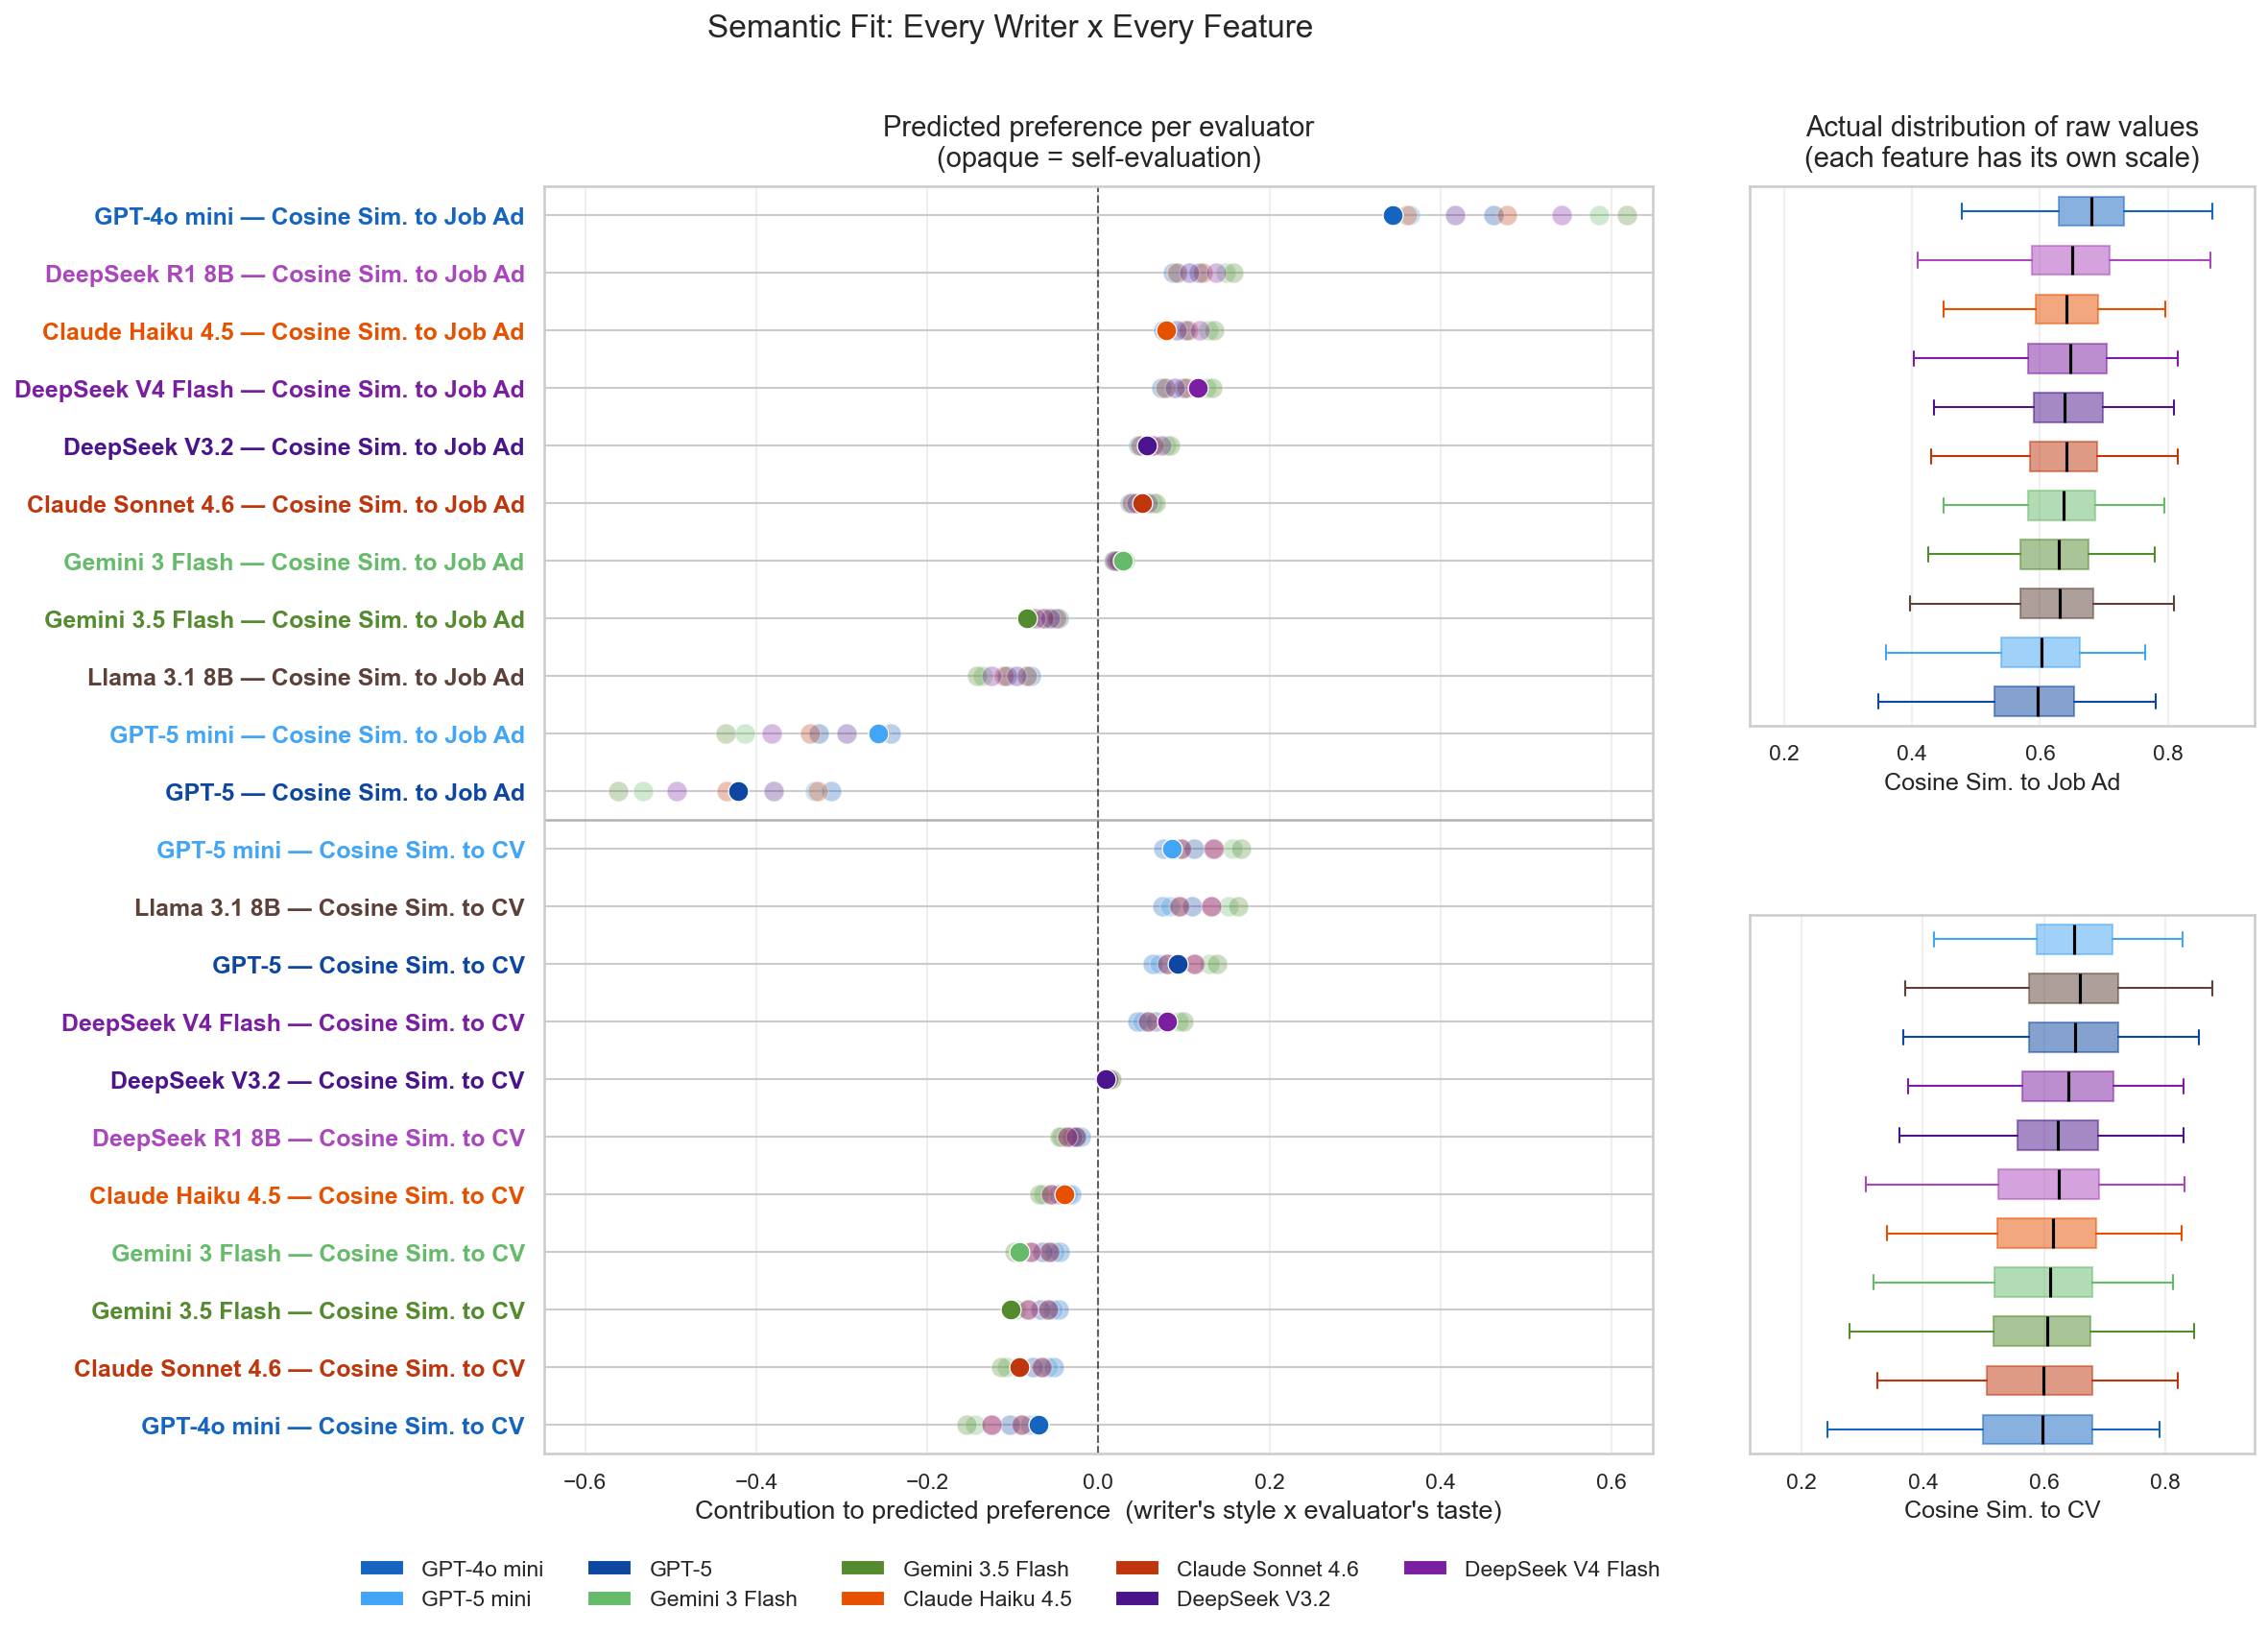

In [7]:
display(Image(f"{CL_DIR}/preference_by_category/semantic_fit.png", width=1400))

This is the same job-ad-echo story as §1, now with every evaluator visible per writer.
GPT-4o mini's strong job-ad echo is rewarded by every evaluator — but **GPT-4o mini itself
rewards it less than most of its peers do** (its opaque dot sits at the low end of the
spread). GPT-5's weak job-ad echo is penalized by everyone — and **GPT-5 penalizes itself
hardest of all** for it (its opaque dot is the most negative in that row). Two very
different relationships to one's own semantic-fit habits, visible only once every
evaluator's dot is shown side by side.


### 5b. Length & Structure

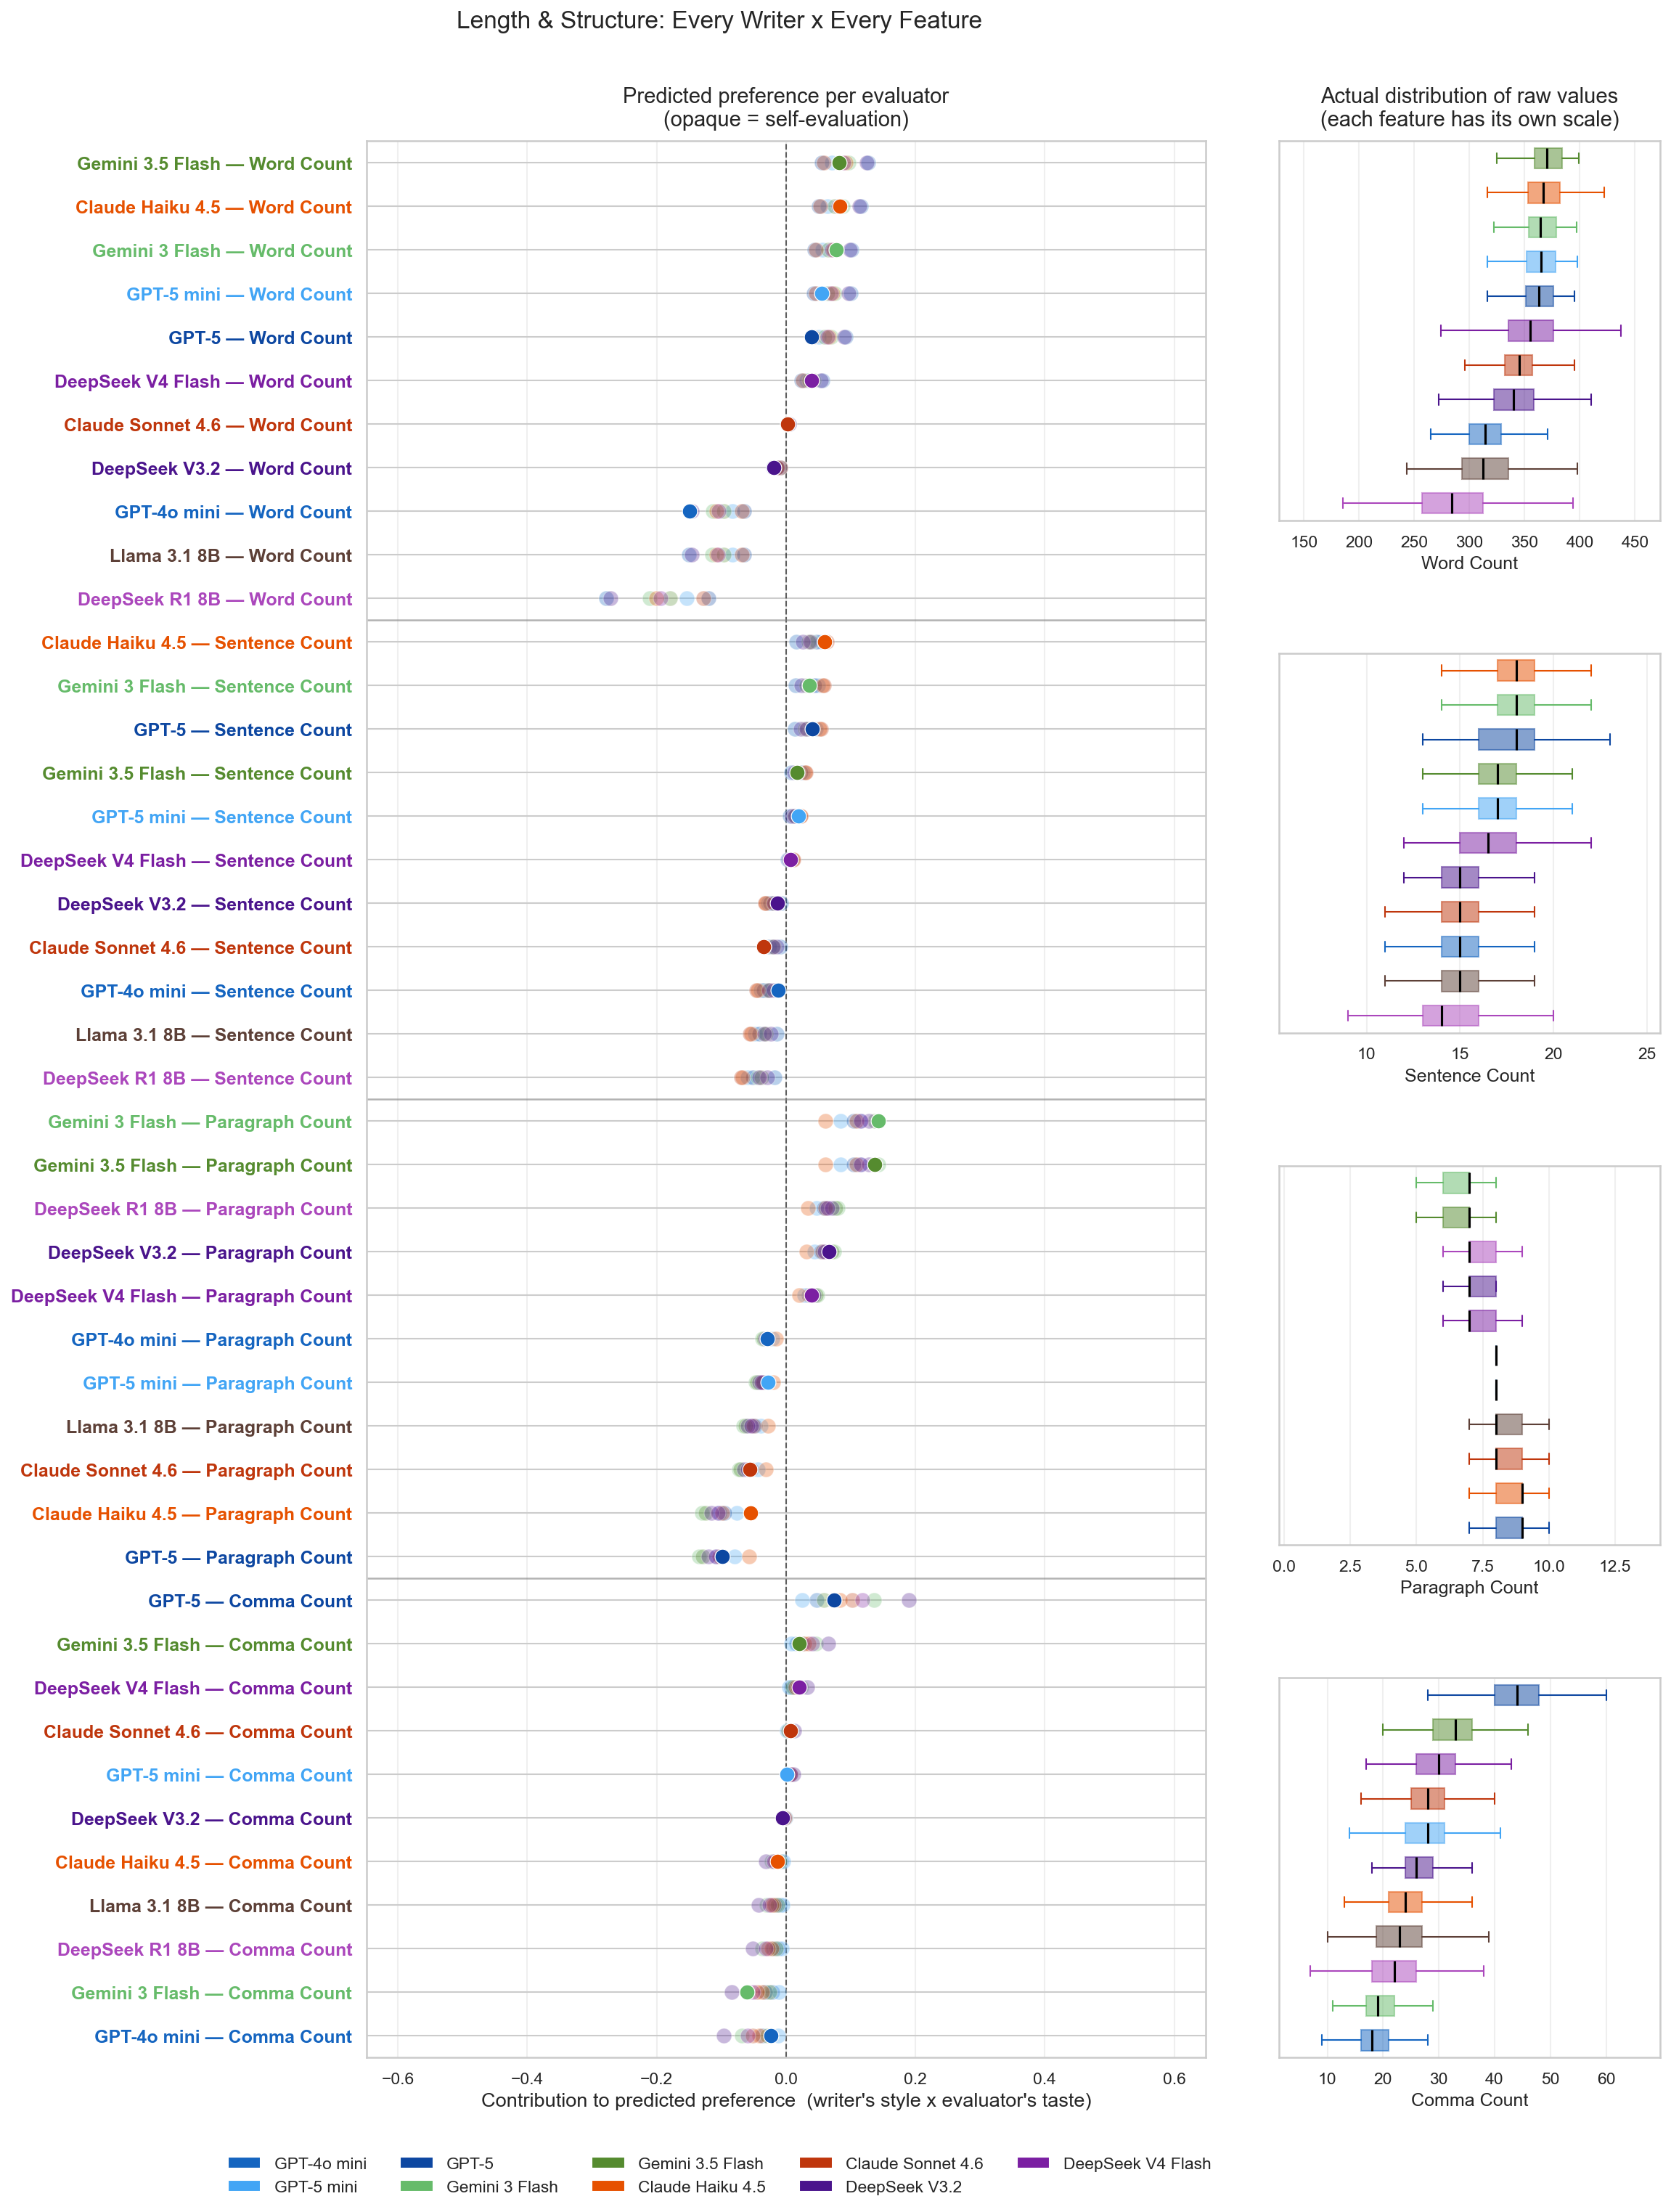

In [8]:
display(Image(f"{CL_DIR}/preference_by_category/length_structure.png", width=1400))

Word count dominates this category — comma, sentence, and paragraph counts contribute far
less on average. The verbose writers (Gemini 3 / 3.5 Flash, GPT-5 mini) sit at one end,
terser writers (DeepSeek R1 8B, GPT-4o mini) at the other, and the sign of the effect
varies by evaluator rather than being uniformly positive or negative — length is rewarded
by some evaluators and penalized by others, unlike the near-universal job-ad-fit
preference in §5a.


### 5c. Language Complexity

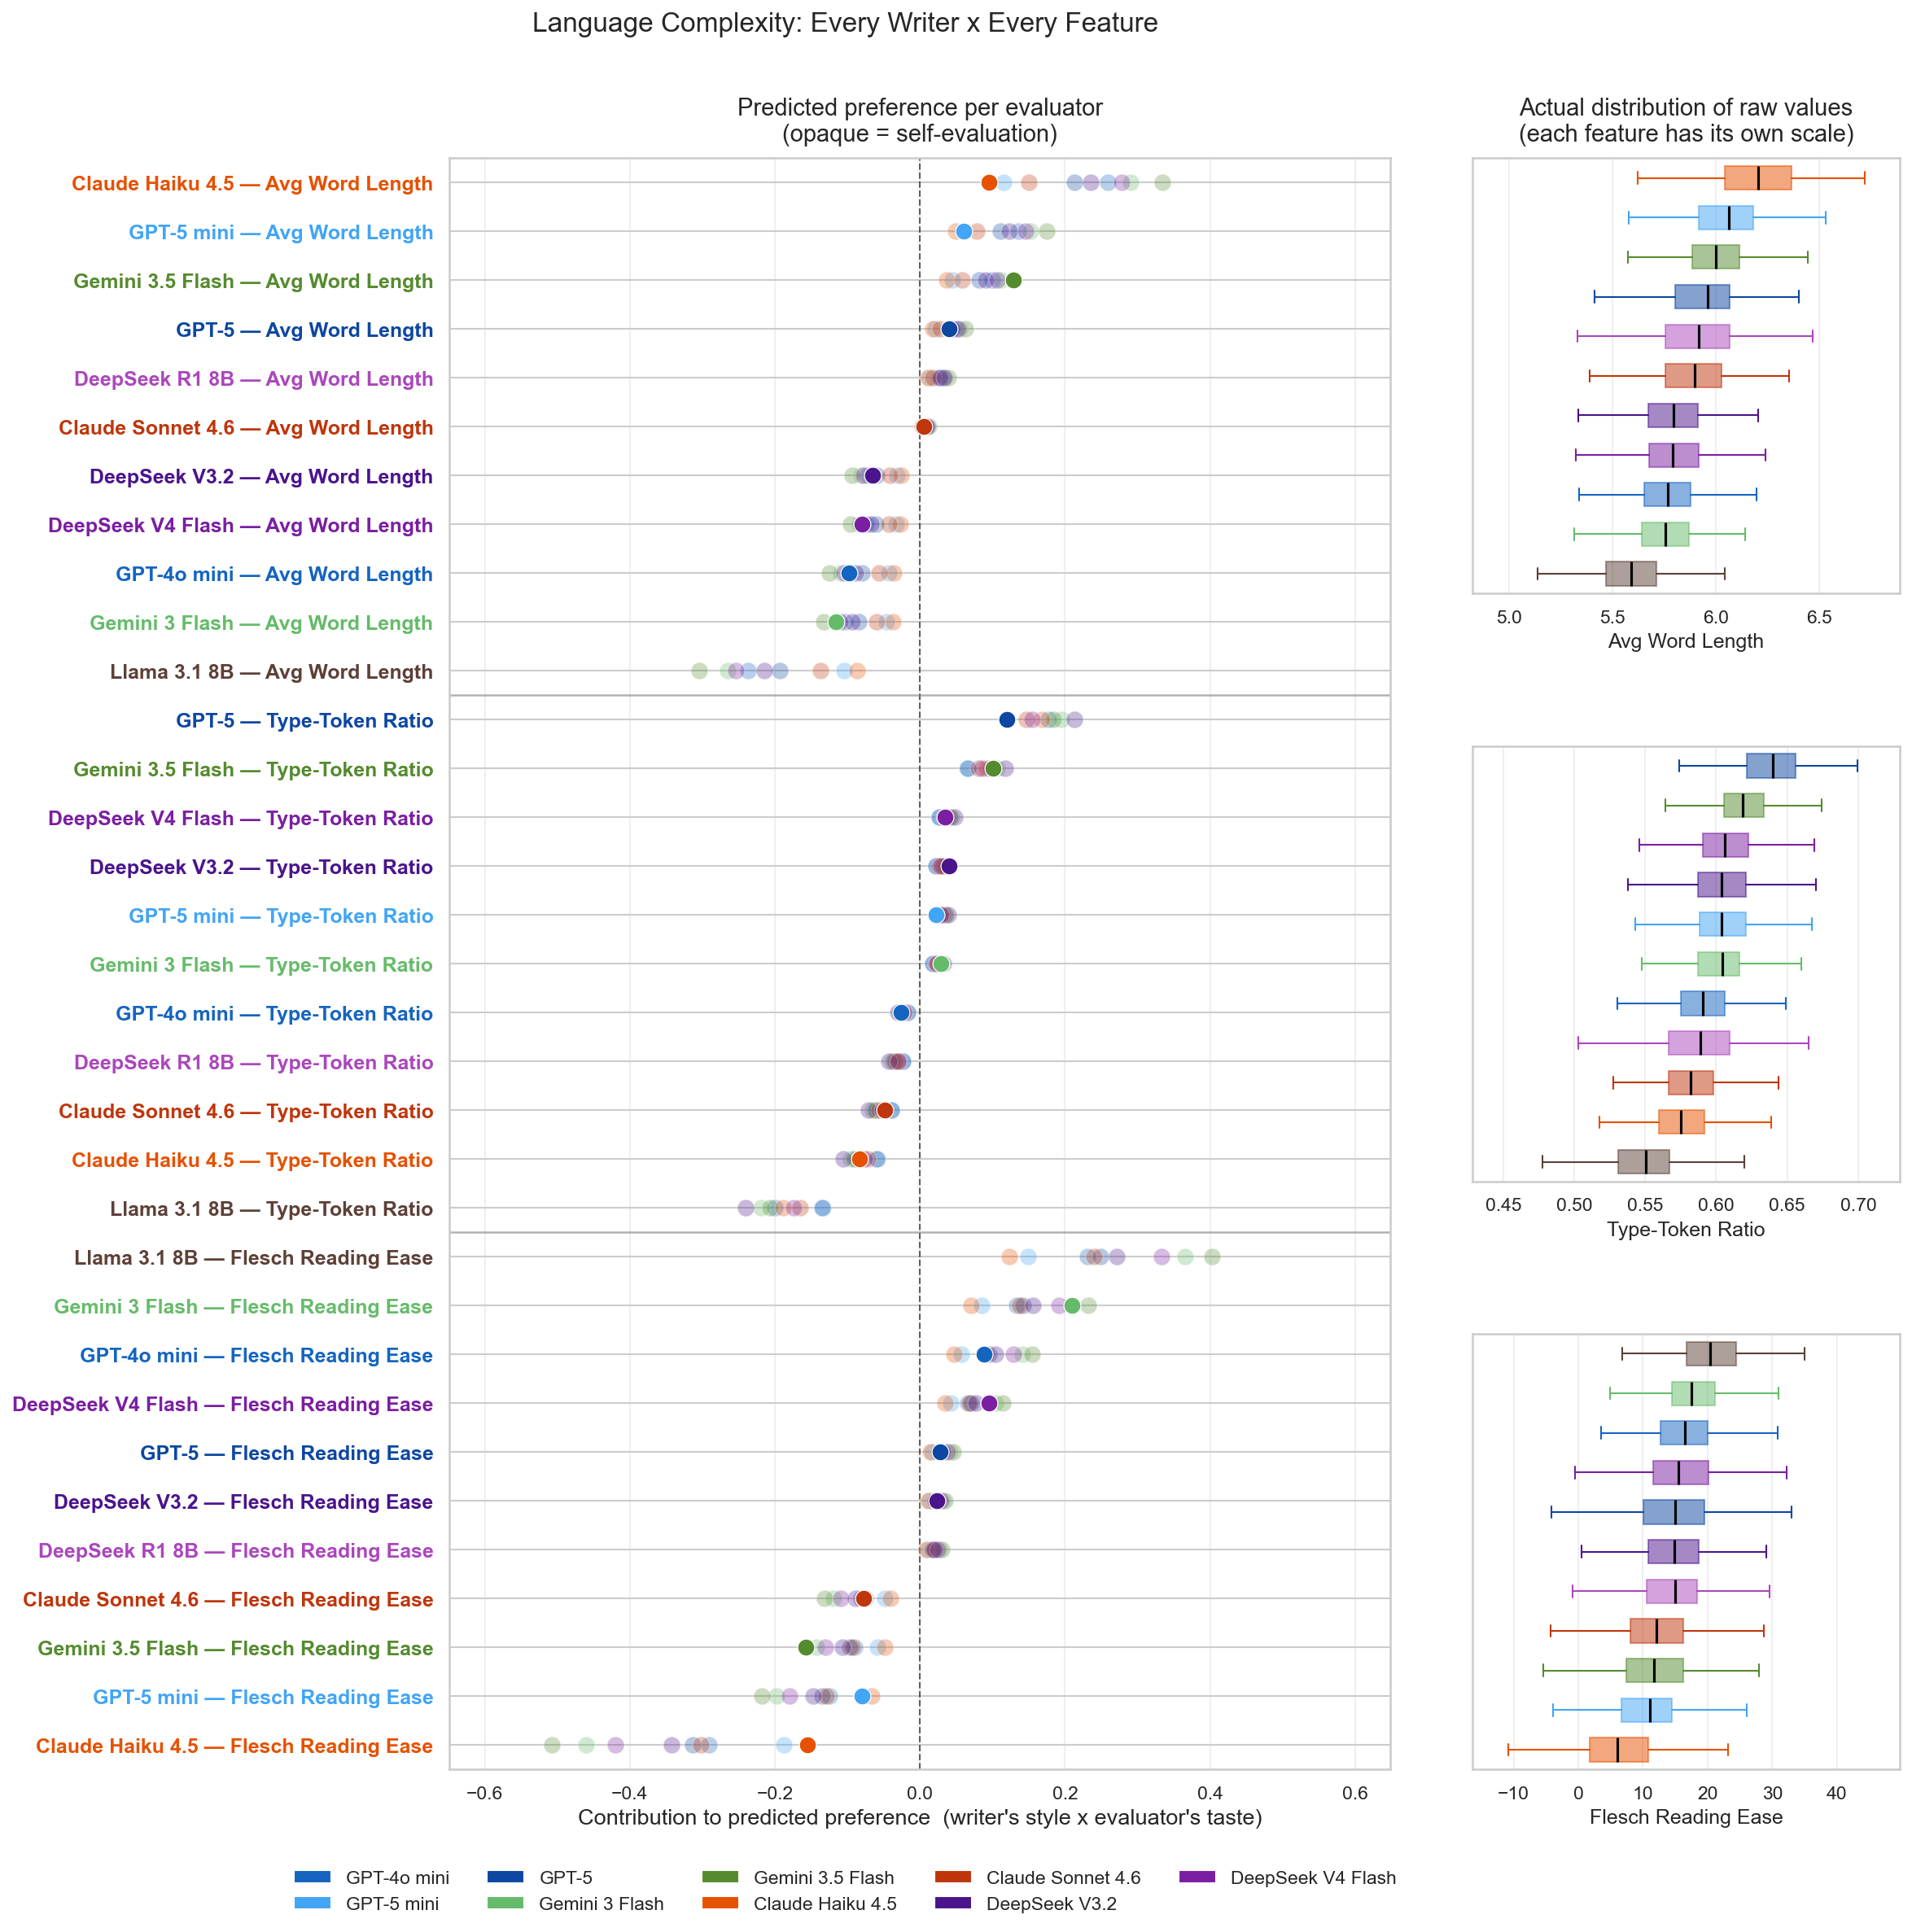

In [9]:
display(Image(f"{CL_DIR}/preference_by_category/language_complexity.png", width=1400))

Directly confirms §2: Claude Haiku 4.5's long words are rewarded and its low readability
is penalized by almost every evaluator — **except by Claude Haiku 4.5 itself**, whose
opaque dot on the Flesch Reading Ease row is by far the least negative of the group (close
to zero, vs. roughly -0.5 for the harshest other evaluators). Llama 3.1 8B shows the exact
mirror pattern (rewarded for high readability, penalized for short words), consistently
across evaluators — it isn't itself an evaluator, so there's no self-dot to compare
against.


### 5d. Sentiment & Affect

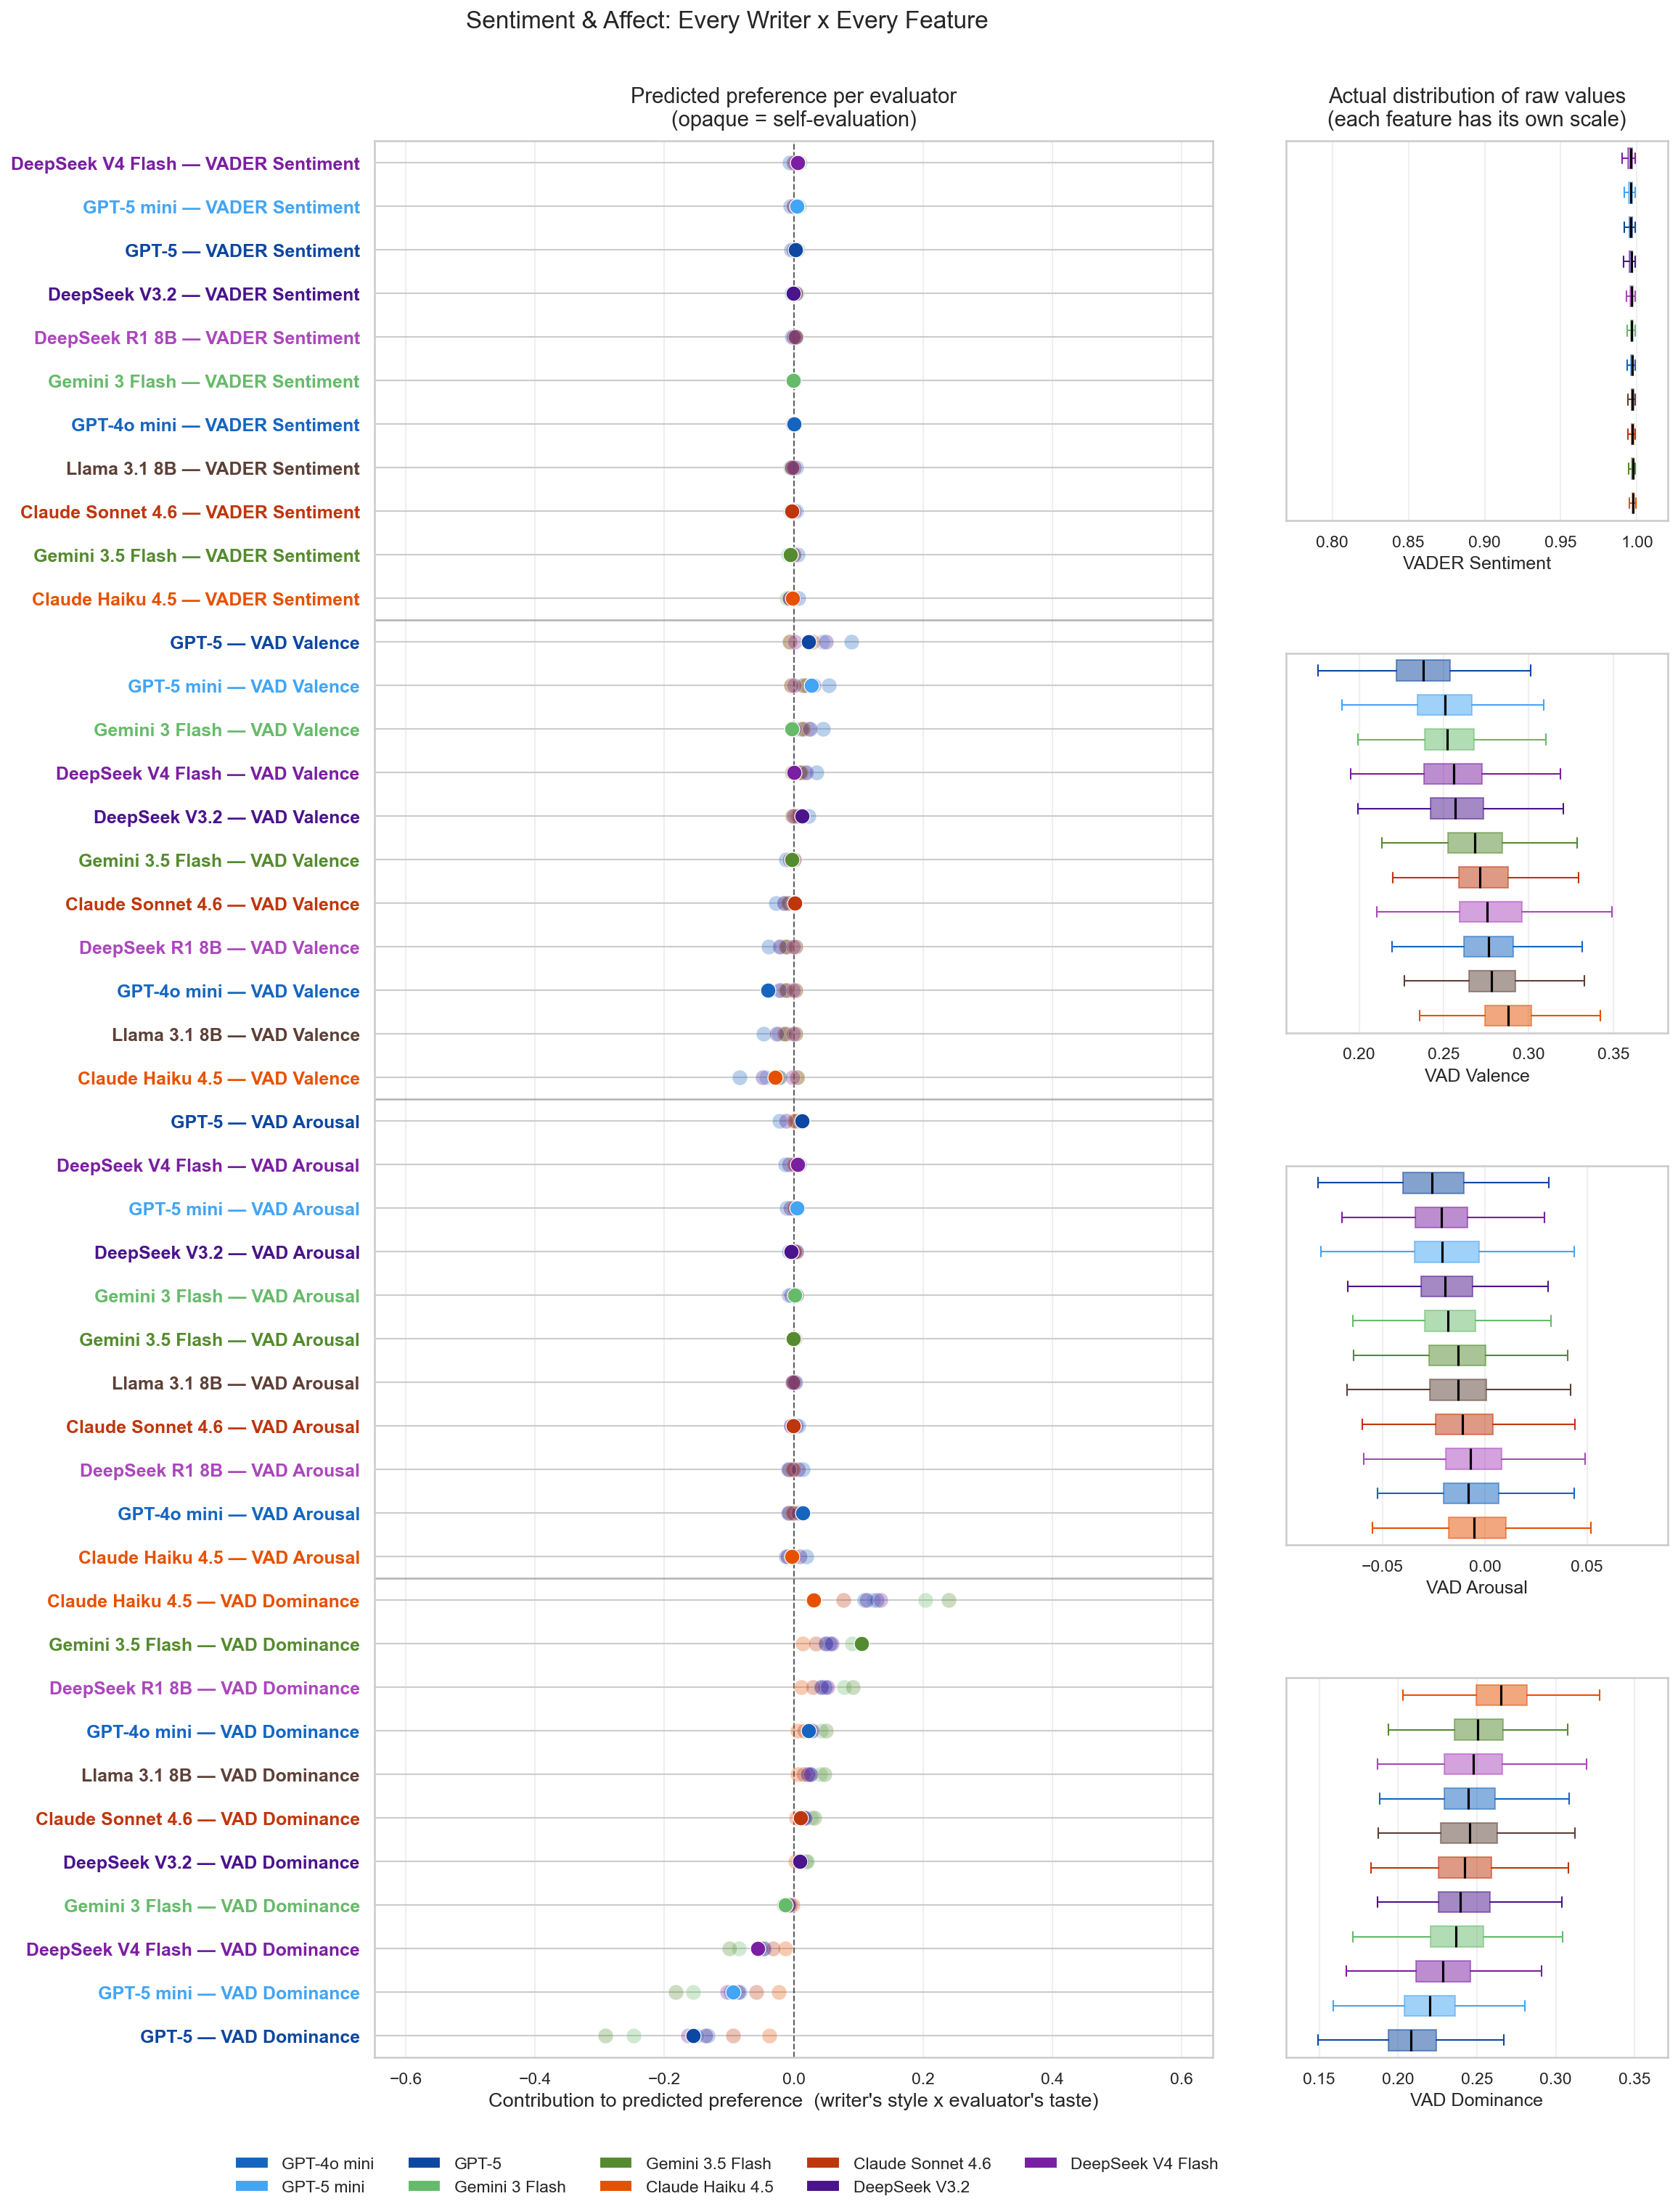

In [10]:
display(Image(f"{CL_DIR}/preference_by_category/sentiment_affect.png", width=1400))

VAD Dominance produces the largest, most consistent contributions in this category
(matching §3); VADER sentiment and VAD Valence contribute almost nothing, consistent with
notebook 1's finding that sentiment is near-uniformly positive across the whole roster and
therefore can't discriminate writers.


### 5e. Emotions

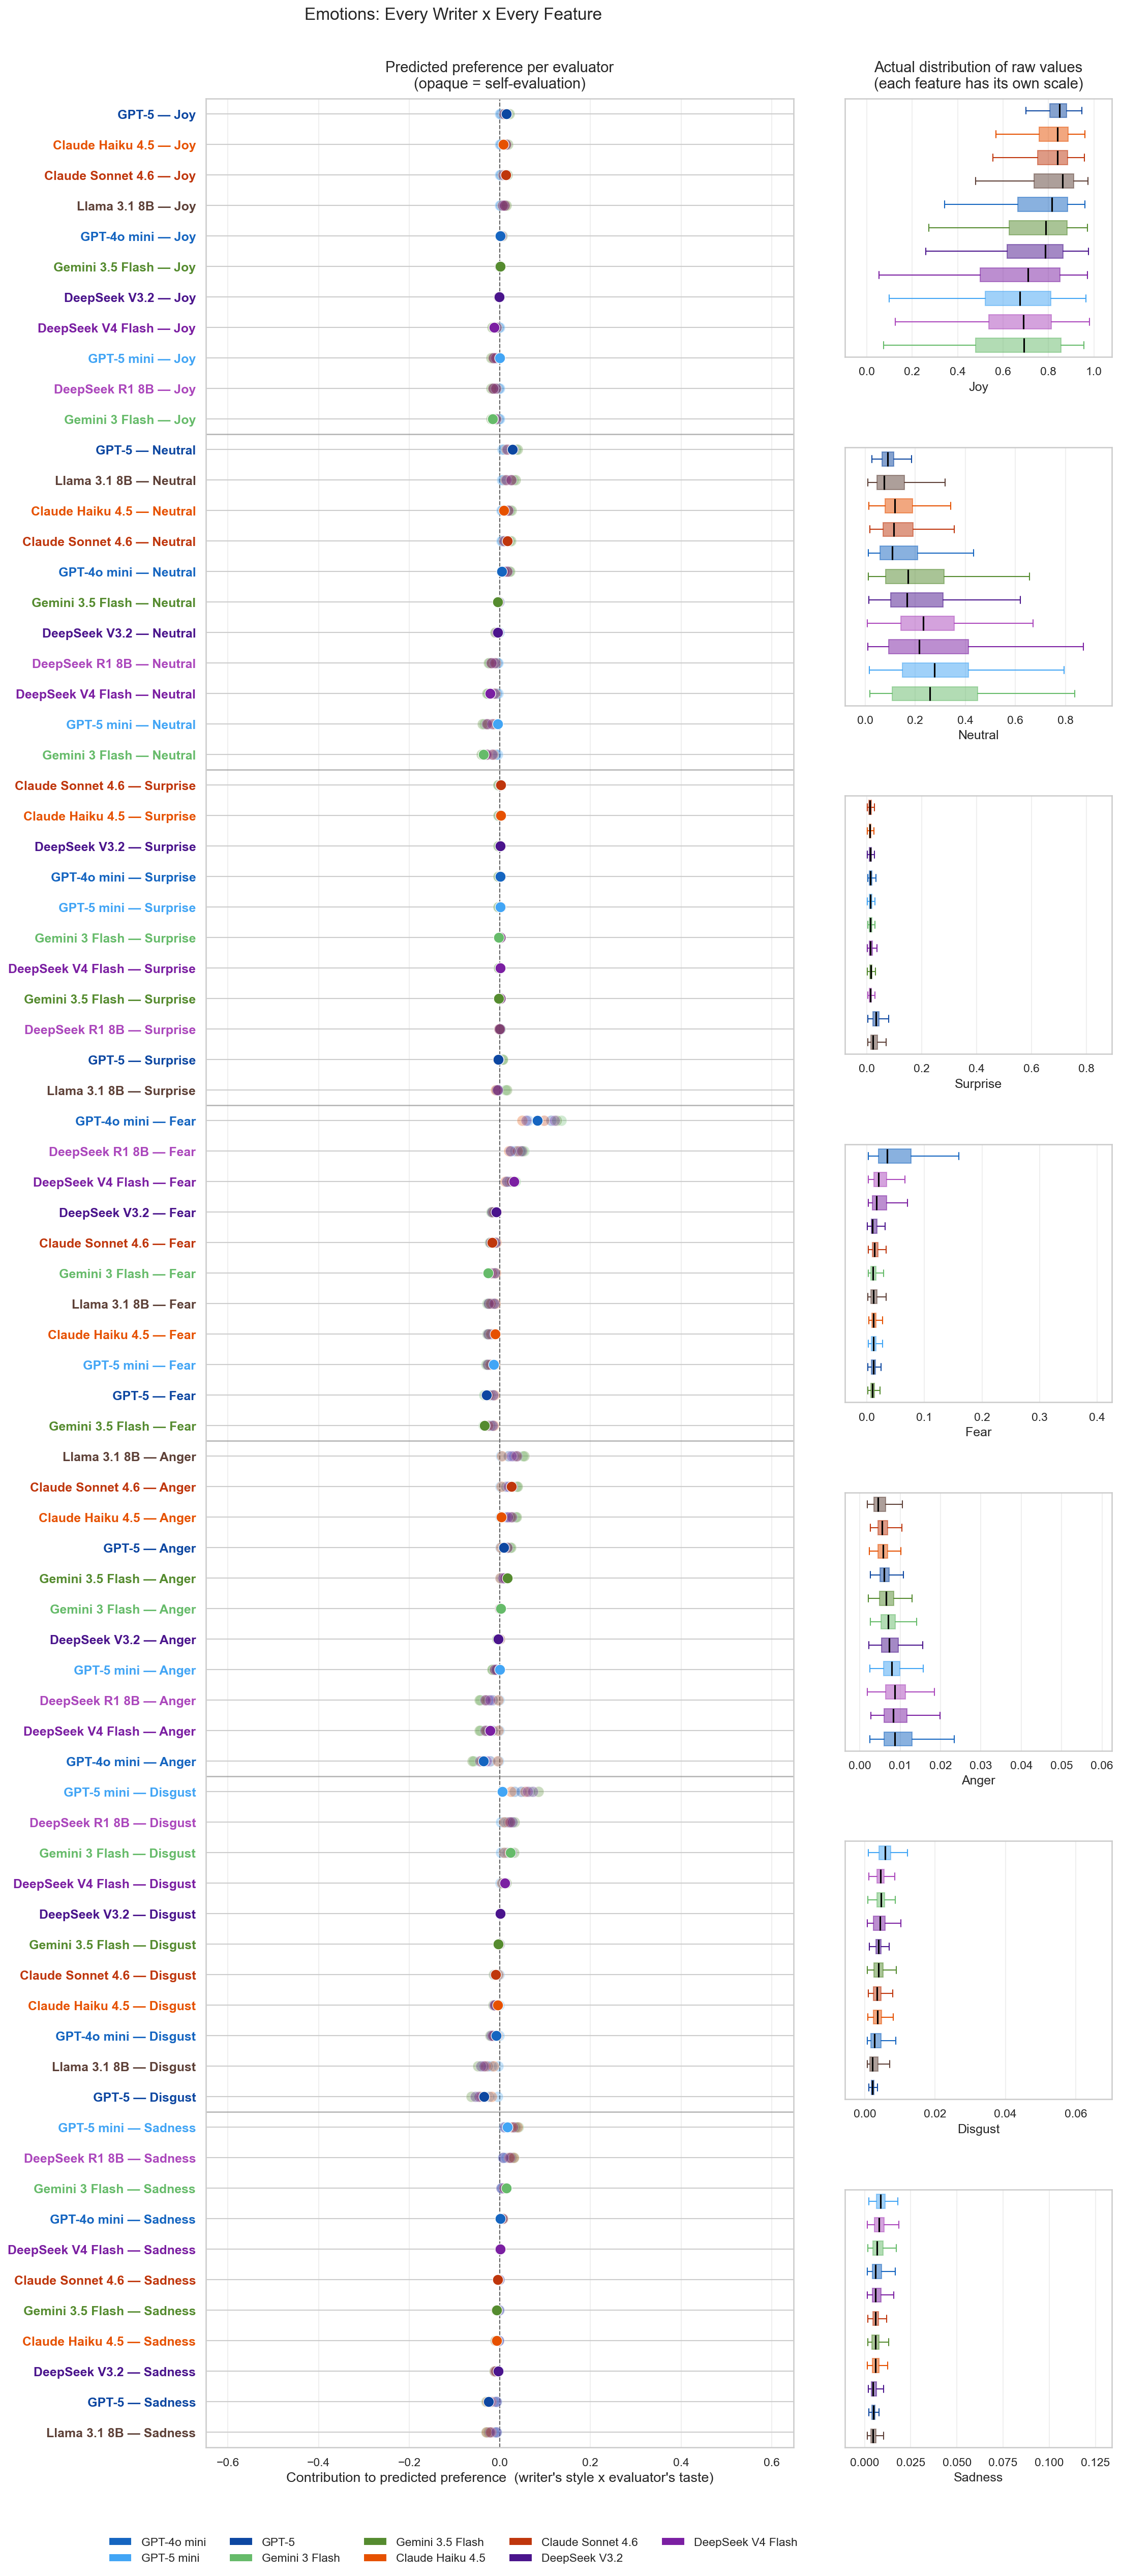

In [11]:
display(Image(f"{CL_DIR}/preference_by_category/emotions.png", width=1400))

Emotions barely register at all — contributions here are an order of magnitude smaller
than in any other category (note the x-axis would need to be zoomed in ~10x to see most
rows clearly). The one partial exception is **GPT-4o mini's elevated Fear**, which is
mildly rewarded by several evaluators. Otherwise, this confirms notebook 3's finding that
readability and word choice, not emotional tone, are what evaluators actually respond to.


### 5f. Self-Points Summary — Every Feature, One Row Each

§5a-5e each show every writer x every feature within one category, with every evaluator's
dot visible. This collapses that down to **one row per feature, across all five
categories**, keeping only the self-evaluation dot for each of the nine writer/evaluator
dual-role models (the two writer-only local models have no self dot, so they're absent
here). Two independent visual channels, each answering a different question:
- **x-position** — self contribution to predicted preference (own style x own taste), same
  quantity as §5a-5e's opaque dots.
- **dot size** — an effect size: `|own mean - feature's overall mean| / feature's own
  population std` (letter-to-letter variability) — the same standardisation logic as the
  Cohen's d tier-effect heatmap in notebook 1. Centring on the mean rather than the raw
  min/max range matters: a couple of outlier letters can drag a min-max midpoint far from
  where almost everyone actually sits (this happened with VADER Sentiment early on and
  made every model look artificially extreme). Sizes use ONE global scale across all 180
  (feature, model) pairs, not a per-row scale — so a feature where every model clusters
  tightly (e.g. VADER Sentiment) comes out uniformly tiny, and a feature with real spread
  (e.g. Cosine Sim. to Job Ad) shows a real range. A per-row scale would have hidden that
  distinction entirely, since it always stretches every row to fill the same size range
  regardless of whether the real differences are trivial or large.
- **marker shape** (▲/▼) — the *direction* of that effect: ▲ if the model's own mean is
  above the feature's overall mean (across all 11 writers), ▼ if below. Size alone gives
  magnitude, not direction — shape recovers that.

(We also tried a marker-border colour for the sign of the raw feature value itself, but
dropped it: almost every feature here is strictly positive by construction — counts,
ratios, cosine similarities, emotion probabilities — so only one row, VAD Arousal, would
ever show anything but the same colour, not worth a whole legend entry. We also tried
standardising by each model's *own* std instead of the pooled population std — dropped
that too, since it reintroduces the same instability from the other direction: a very
consistent writer would get its size inflated by dividing by its own tiny std, even for a
trivial mean deviation.)

Reading a row: a big triangle far from the dashed zero line is a model that writes that
feature in an unusually extreme way *and* has a strong, consistent self-taste about it —
positive if it's to the right, negative if to the left. A big triangle sitting near zero is
a model that writes that feature extremely but whose own evaluation taste doesn't
particularly reward or punish that extremity.


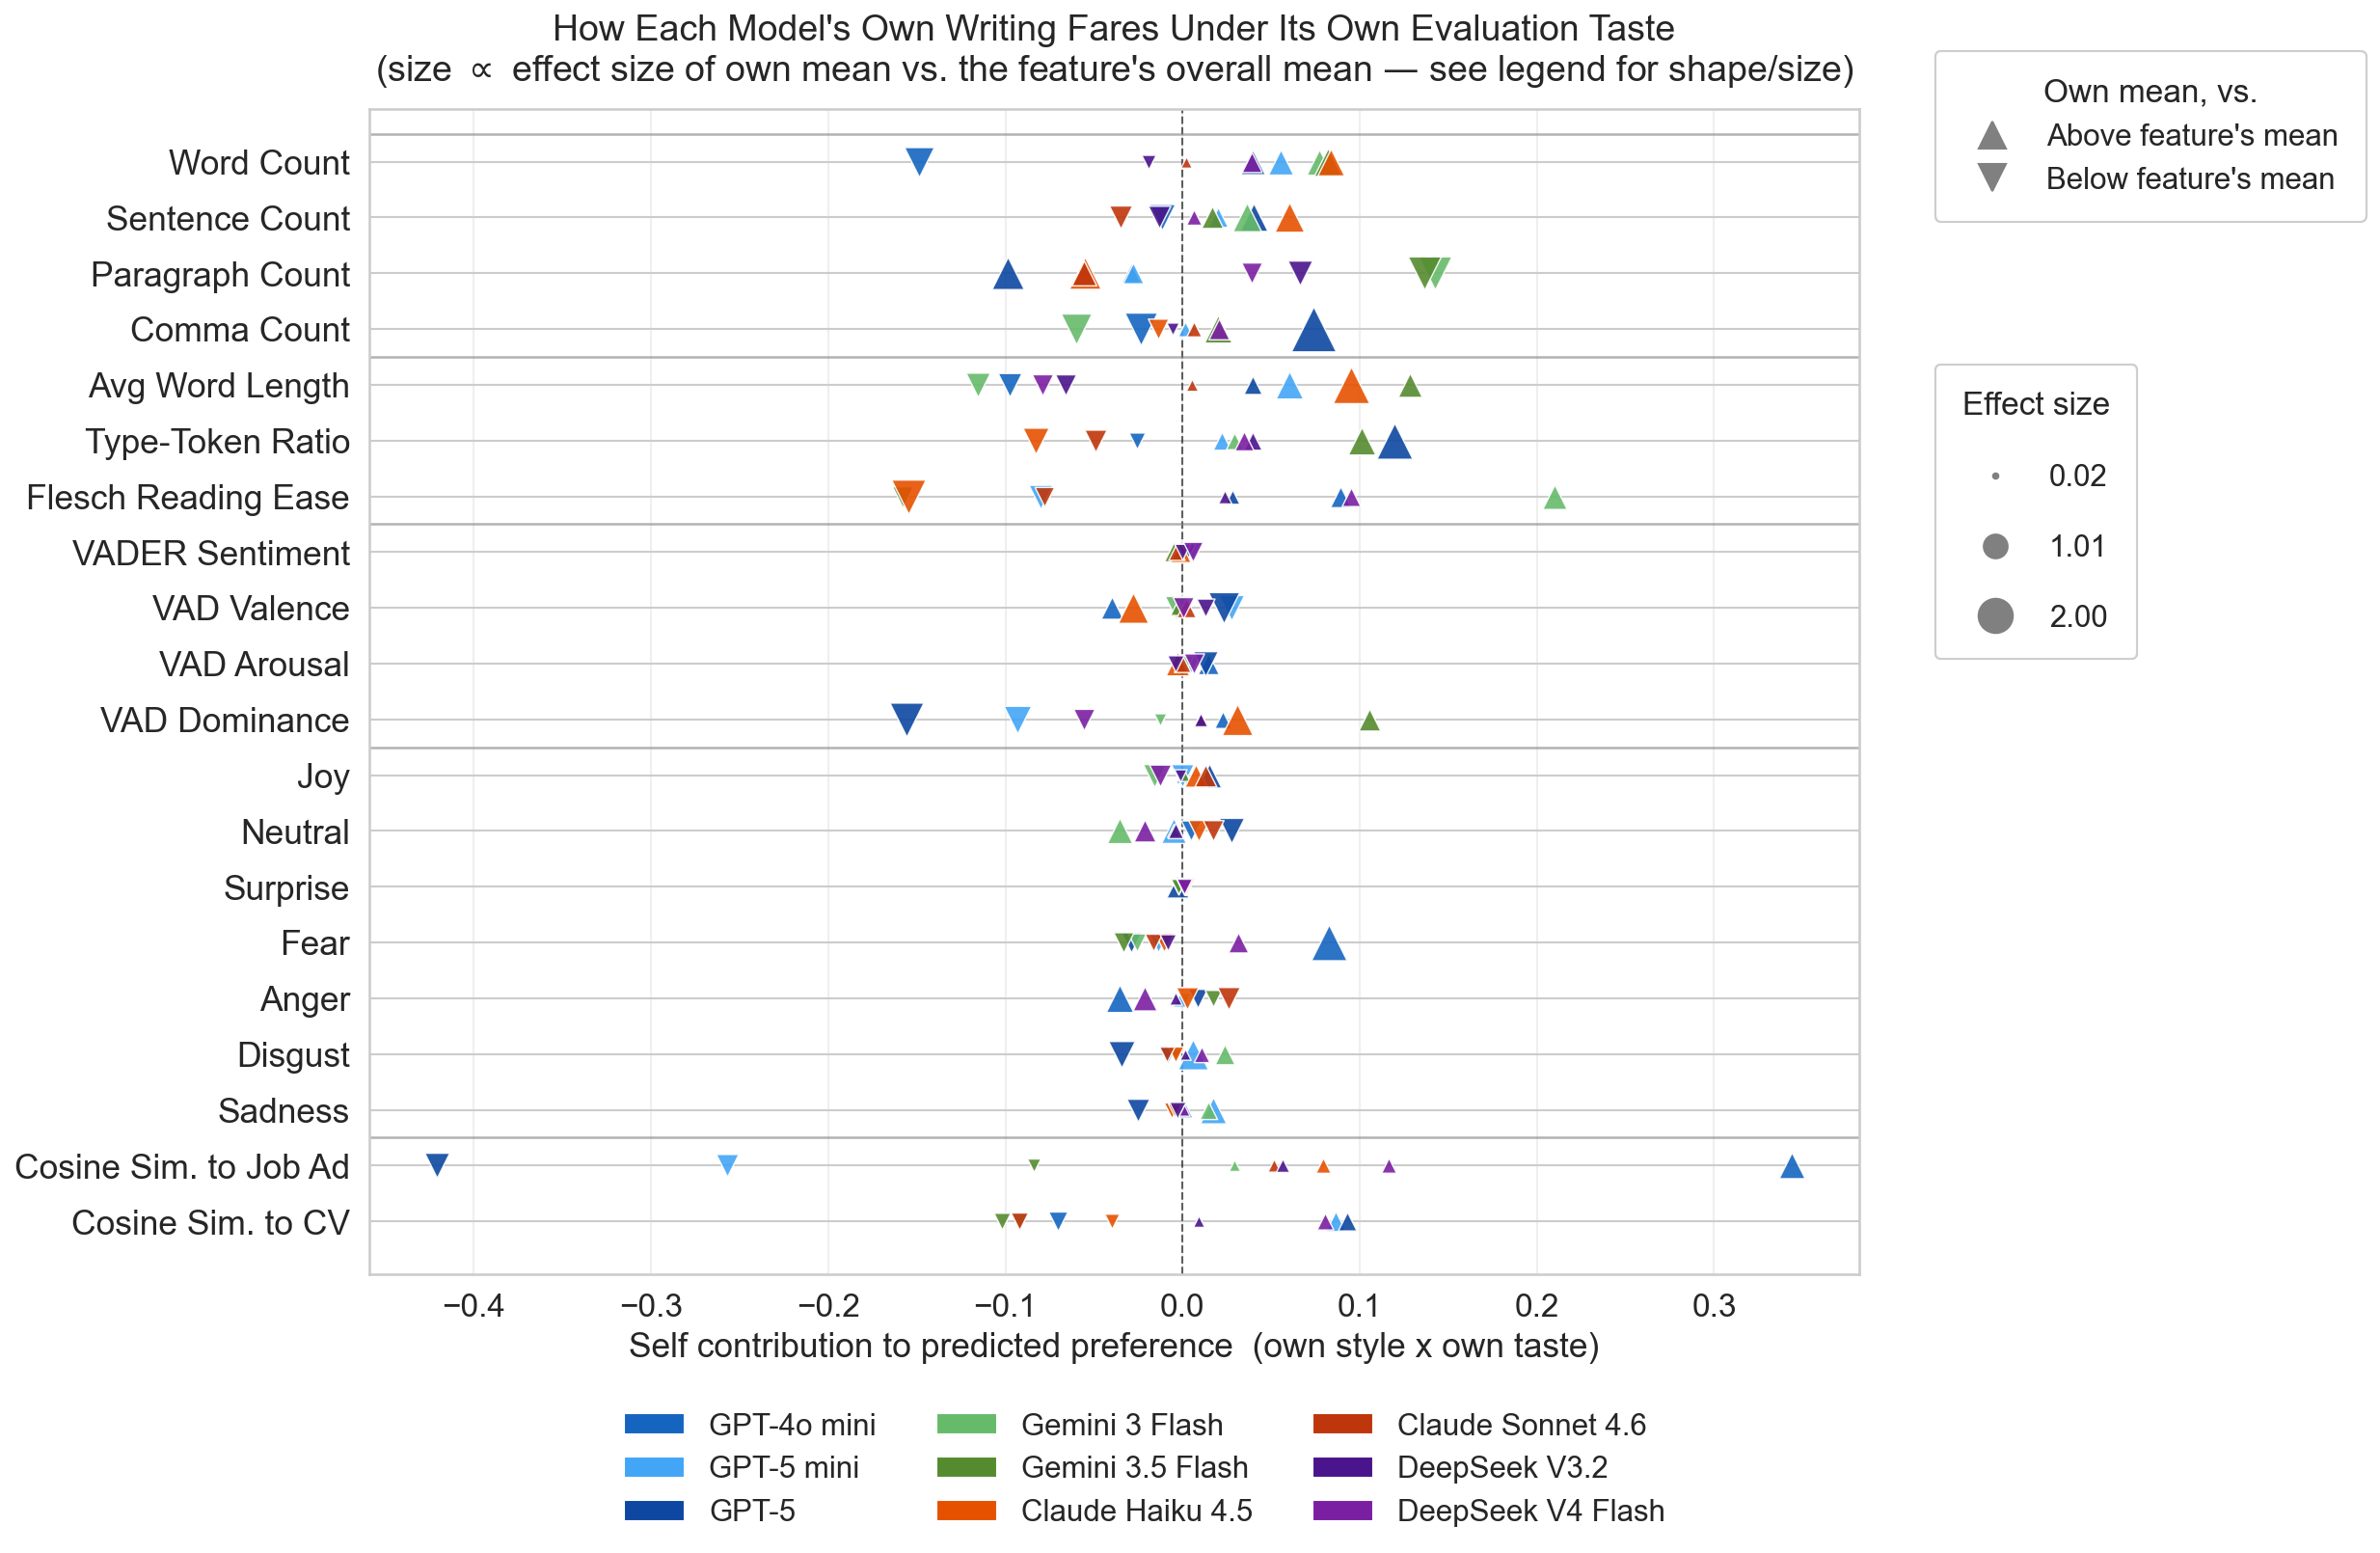

In [12]:
display(Image(f"{CL_DIR}/self_points_summary.png", width=1400))

**Key finding:** the single most extreme row is **Cosine Sim. to Job Ad** — GPT-4o mini's
dot is both the largest in the whole figure and the furthest right (+0.34): it writes the
most job-ad-echoing letters of any dual-role model *and* rewards that trait in itself
strongly. GPT-5 sits at the opposite extreme on the same feature, nearly as large but far
to the left (-0.42): it echoes the job ad the least of any dual-role writer, and penalizes
that low echo in itself just as strongly. The two most self-consistent writers on this
feature are also its two biggest outliers — self-preference here isn't a subtle nudge, it's
large and in the direction their own writing already leans. Large dots cluster heavily in
Semantic Fit and Language Complexity (Flesch Reading Ease, Paragraph Count, VAD Dominance
also show sizeable, non-central dots), and are visibly smaller and more clustered near zero
in Sentiment & Affect and Emotions — confirming, from a different angle than §5a-5e, that
the features carrying real self-preference signal are concentrated in how a letter reads
and how closely it tracks the job ad, not in its emotional register.


### 5g. Common Preference Summary — Which Features Does (Almost) Everyone Reward?

§5f is about self-preference: does a model's own taste line up with its own writing habits?
This is the complementary, non-self-referential question: **forget self-preference
entirely — which features do evaluators, in general, reward or penalise, and how much do
they agree?** One row per feature again, in two panels. **Left:** every dot is one of the
nine evaluators' own (standardised) Ridge coefficient for that feature — how much a unit of
that feature moves the score, holding every other feature fixed — with a bold black diamond
for the cross-evaluator mean. **Right:** every dot is one of the eleven writers' own mean
value for that feature (standardised the same way, mean ± 1 std as an error bar) — how much
that writer actually uses the feature, and how consistently. Rows are shaded when all nine
evaluators agree in sign (left panel): green for unanimous reward, red for unanimous
penalty, shading carried across both panels so a row reads as one unit. Putting both panels
side by side turns "is this rewarded" and "who actually does it" into a single glance per
feature.


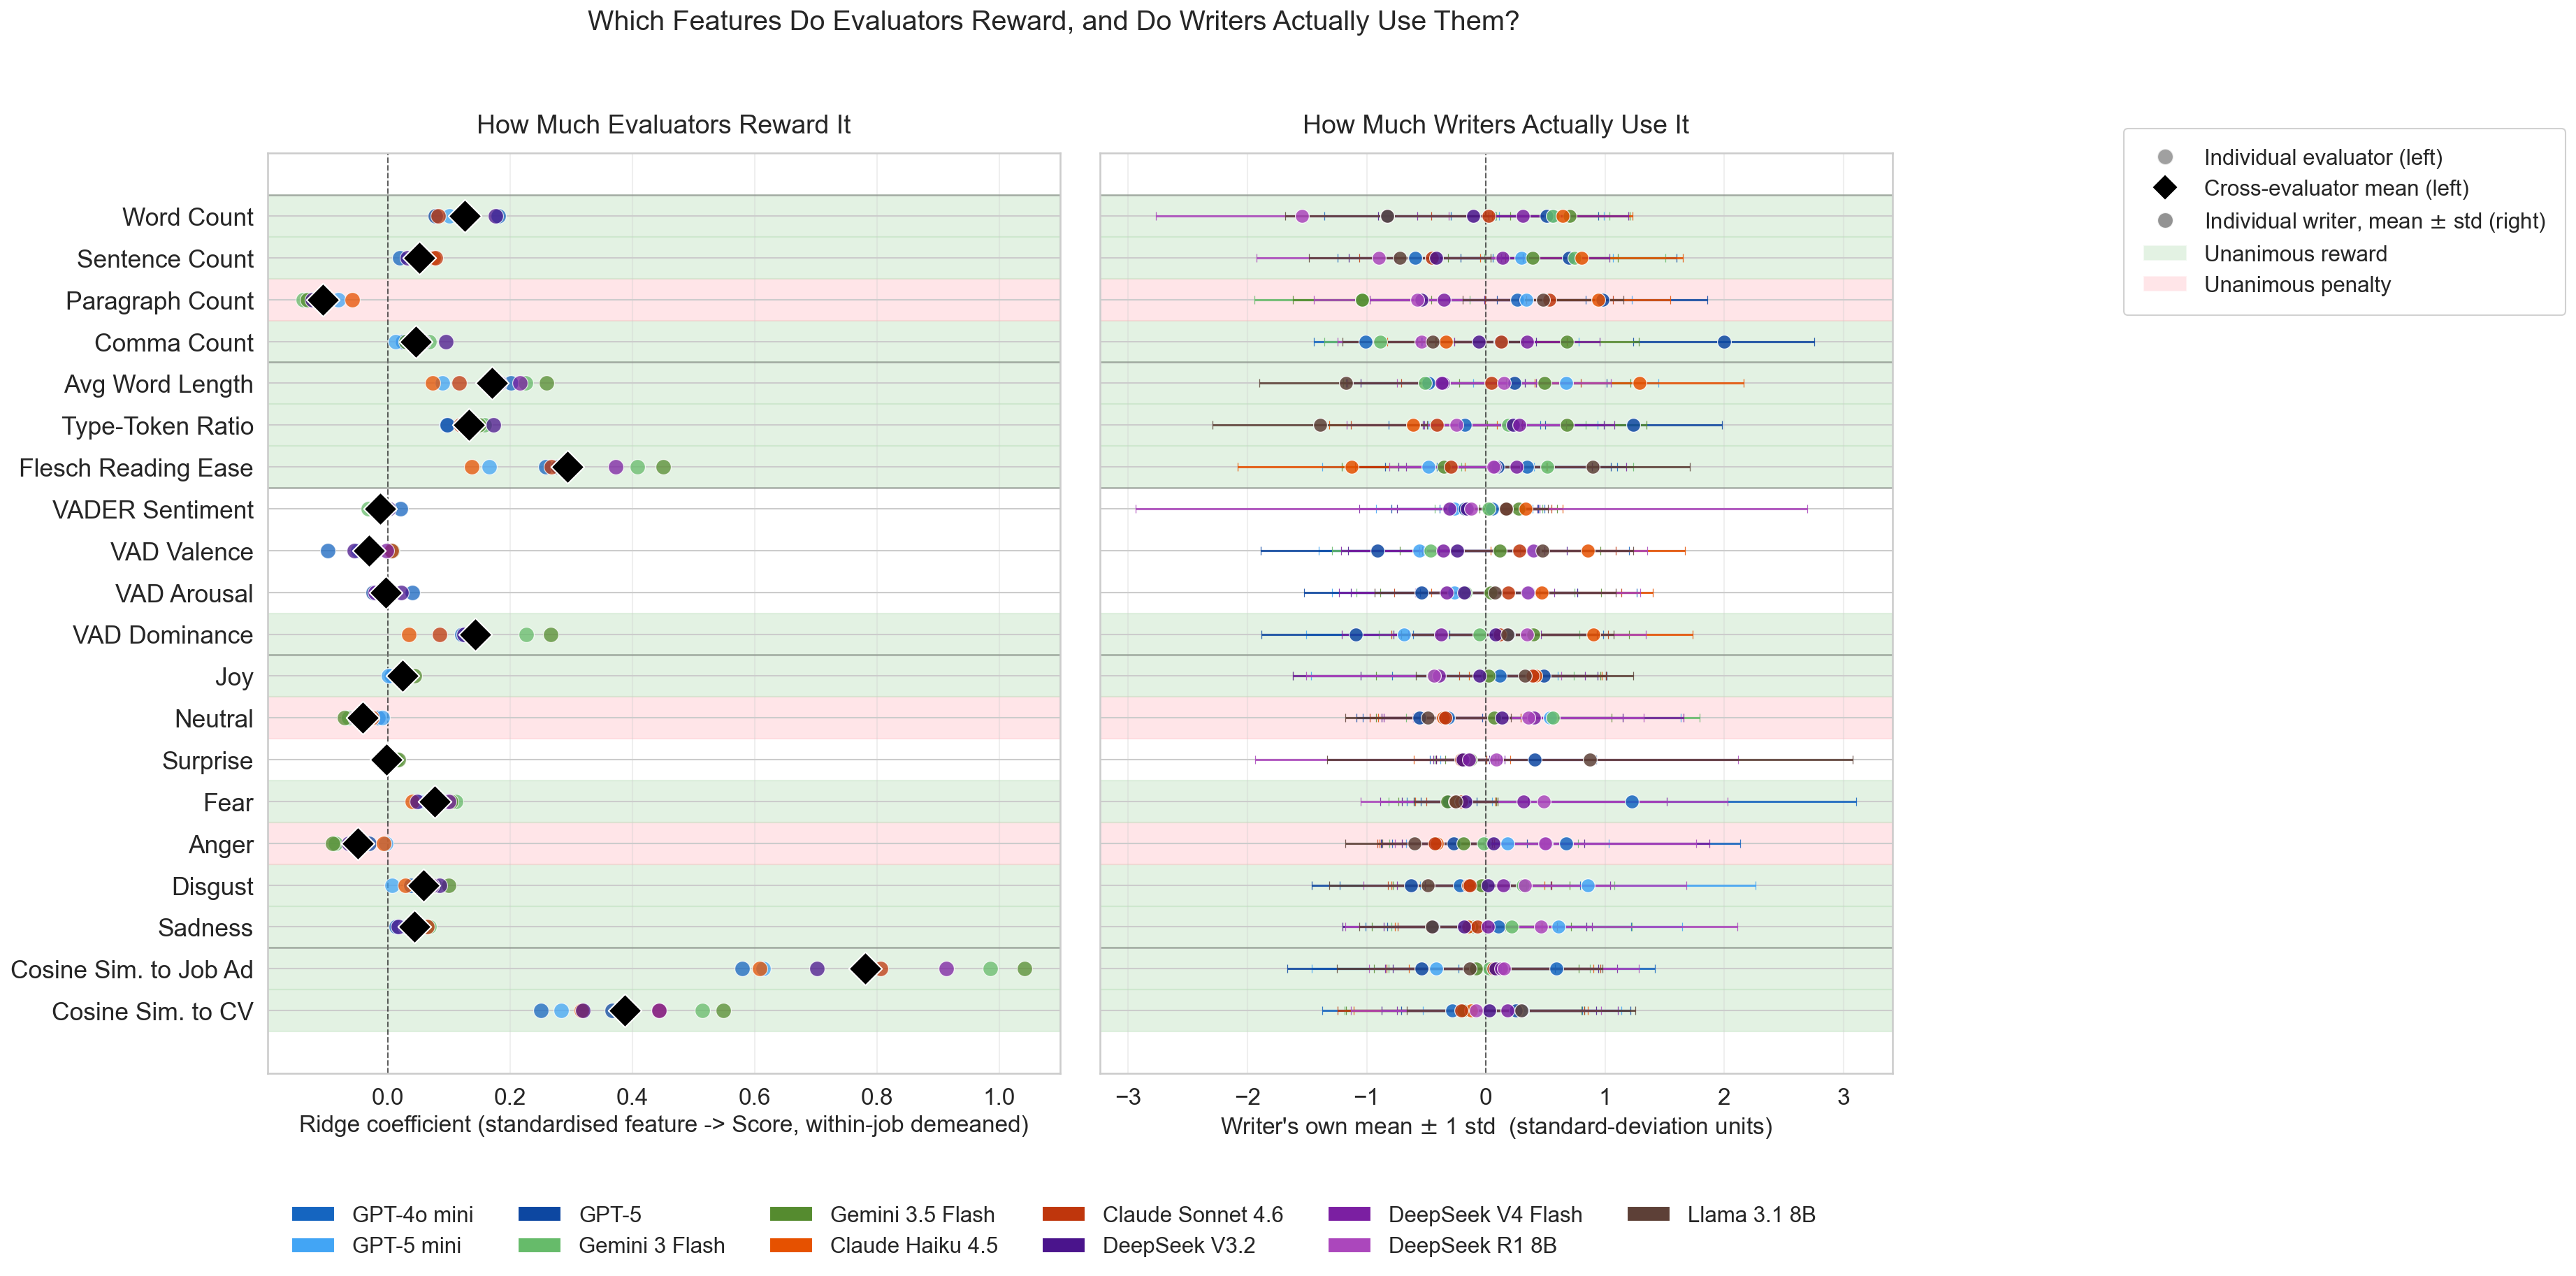

In [13]:
display(Image(f"{CL_DIR}/common_preference_summary.png", width=1400))

**Key finding:** **Cosine Sim. to Job Ad is, by a wide margin, both the most strongly and
the most unanimously rewarded feature of the twenty** — every evaluator's coefficient is
positive and the cluster sits far to the right (cross-evaluator mean ≈ 0.78, more than
double the next highest feature), with no other feature coming close. Cosine Sim. to CV
(mean ≈ 0.39) and Flesch Reading Ease (mean ≈ 0.30) are the next most strongly and
unanimously rewarded. On the other side, **Paragraph Count, Anger, and Neutral are the
clearest unanimous penalties** — every evaluator's coefficient is negative for all three,
though the magnitudes are much smaller than the semantic-fit rewards. Most Length &
Structure and Language Complexity features are unanimously rewarded (all nine agree in
sign), while Sentiment & Affect is where consensus breaks down most: VADER Sentiment, VAD
Valence, VAD Arousal, and Surprise are the only rows with no shading at all, i.e. evaluators
actually disagree on which direction to reward — not just on how much, but on the sign
itself. Read together with §5f: the feature evaluators reward most in general (Cosine Sim.
to Job Ad) is also exactly where GPT-4o mini and GPT-5 showed the largest, most opposite
self-preference effects — the biggest lever in the whole preference structure is also the
one most subject to self-preference distortion. On the right panel, GPT-4o mini's dot on
Cosine Sim. to Job Ad is the furthest right of any writer on any feature in the whole plot
(z ≈ +0.59, std ≈ 0.83) — the writer that leans hardest into exactly the feature evaluators
reward hardest. §5h turns that observation into an actual per-writer ranking.


### 5h. Who Benefits Most From Universal Preference, and Why?

§5g showed *which* features are rewarded, in general, and *who* uses them, side by side but
separately. This multiplies the two together: for every (writer, feature) pair, `avg
evaluator coefficient x that writer's own standardised usage` — exactly the same
"coefficient x usage" logic as §5g's two panels, just combined into one number per cell
instead of read off two separate dot positions. Summing a writer's row gives their **common
preference score**: how much a "typical" evaluator would like this writer's overall style,
independent of who specifically is judging. This is the direct, quantitative answer to
"do the best writers dominate in the features that (almost) all evaluators reward?"


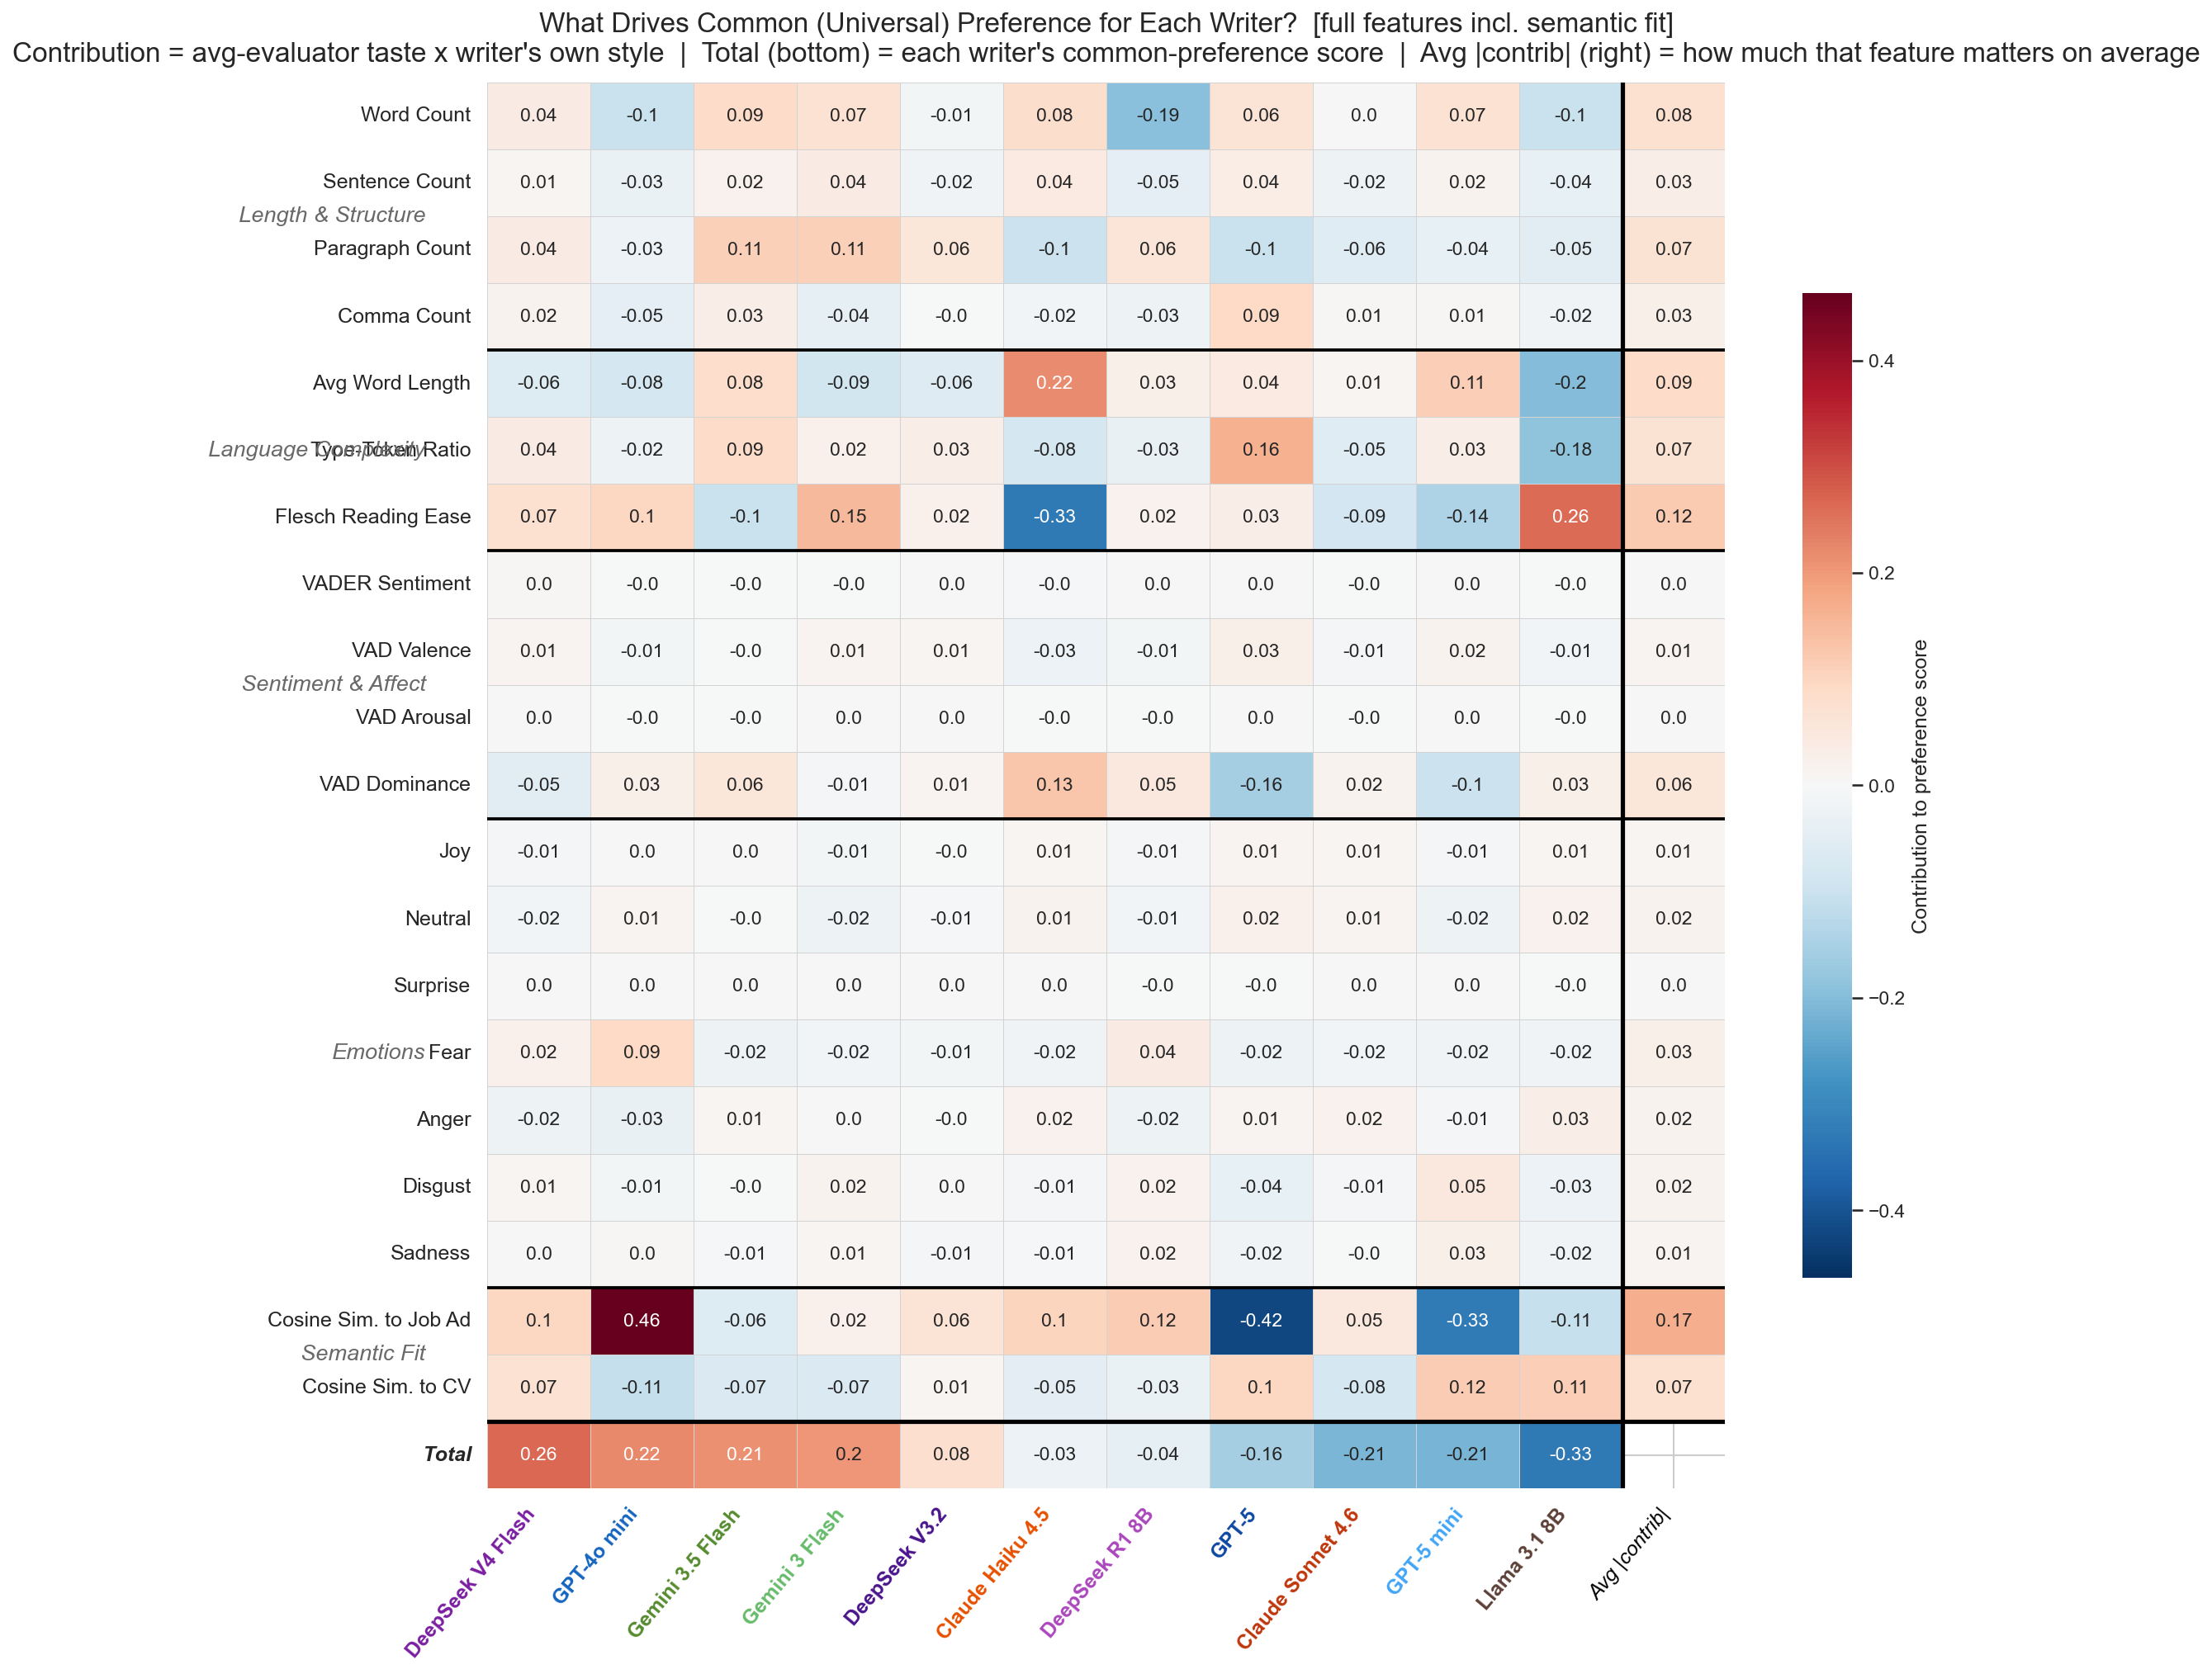

In [14]:
display(Image(f"{CL_DIR}/common_preference_drivers_full.png", width=1400))

**Key finding:** ranking by the **Total** row (common preference score, descending):
**DeepSeek V4 Flash leads (+0.265)**, followed by GPT-4o mini (+0.223), Gemini 3.5 Flash
(+0.212), and Gemini 3 Flash (+0.205); **Llama 3.1 8B trails badly (-0.330)**, with GPT-5
mini (-0.215) and Claude Sonnet 4.6 (-0.211) also clearly negative. But the *shape* of that
success differs sharply between the top two: **GPT-4o mini's score is carried almost
entirely by one feature** — Cosine Sim. to Job Ad alone contributes +0.46, the single
largest cell in the entire heatmap and more than double GPT-4o mini's total score, meaning
its other features are, on net, mildly negative. **DeepSeek V4 Flash's score is spread
across many features instead**: Cosine Sim. to Job Ad (+0.10), Flesch Reading Ease (+0.075),
Cosine Sim. to CV (+0.070), Word Count (+0.039), Paragraph Count (+0.037), and TTR (+0.037)
each contribute a modest amount, none dominant. So "dominate the single most-rewarded
feature" and "have the best overall universal-preference score" turn out to be two different
routes to success, not the same thing — GPT-4o mini takes the concentrated route, DeepSeek
V4 Flash the diversified one, and diversification wins by a narrow margin here. The failure
mode is more concentrated: **GPT-5's weak Cosine Sim. to Job Ad usage is a -0.42 penalty on
its own**, larger in magnitude than its next three contributions combined (VAD Dominance
-0.156, Paragraph Count -0.104, Fear/Disgust -0.037) — one weak feature, on the one feature
that matters most, is most of the story behind GPT-5's below-average common-preference
score.


---
## 6. Ranking Models by Self-Preference

§5's rows already showed self-preference isn't uniform — some models discount their own
strengths, others punish their own weaknesses, others forgive them. This section sums
that up into a single per-model ranking, using the same per-(model, feature) contributions
as §5's dot-plots: `(own taste − average evaluator's taste) x own standardized style`,
summed across the full feature set. Every feature is z-scored before regression, so these
contributions are already unit-free and safe to sum across features.

Two aggregates, shown one row per Eval_Type, because a plain signed sum can hide real
effects through cancellation:
- **Net self-preference** (left column) — signed sum. Can land near zero even when a
  model shows real self-preference on individual features, if those features happen to
  point in opposite directions.
- **Self-preference magnitude** (right column) — sum of `|contributions|`. Never
  cancels — answers "how much does self-preference show up, feature by feature,"
  regardless of sign.


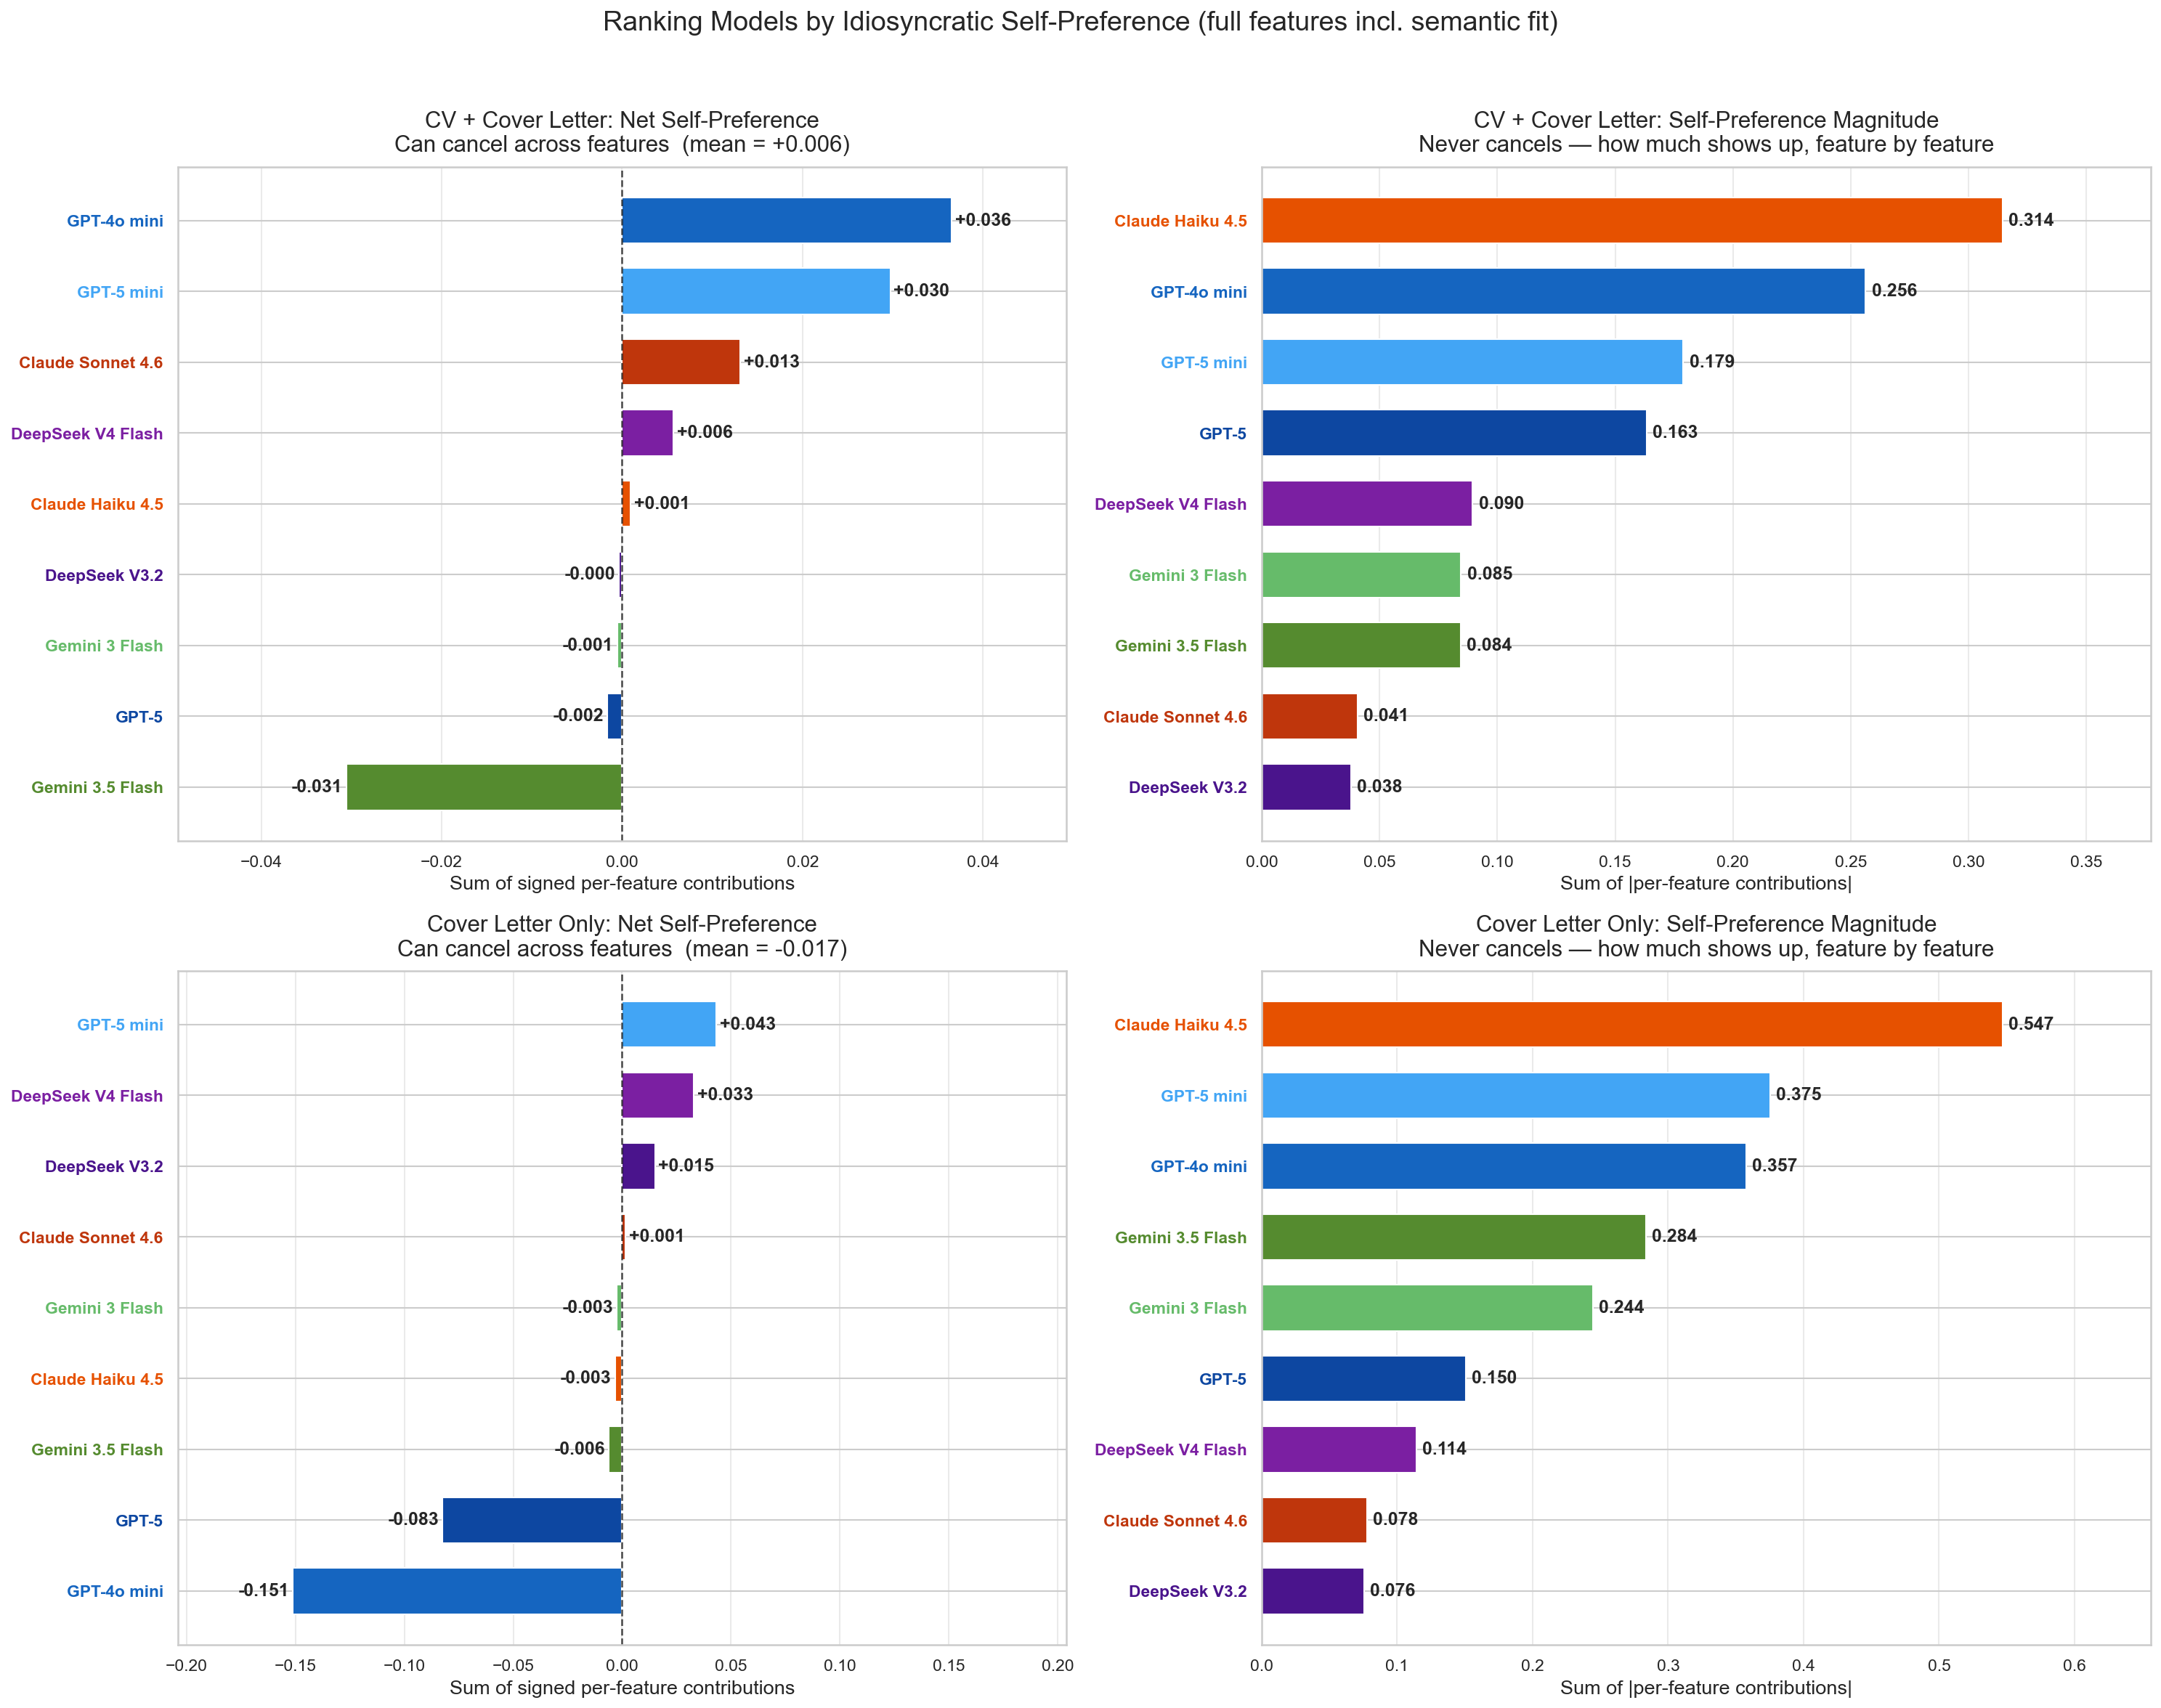

In [15]:
display(Image(f"{CL_DIR}/self_preference_ranking.png", width=1400))

**Key finding:** the two rankings tell different stories. **Claude Haiku 4.5 tops the
magnitude ranking in both scenarios** (0.31-0.55, well ahead of the rest of the roster)
even though its *net* self-preference is close to zero — small self-deviations spread
across several features (avg word length, VAD dominance, and others, each modest alone)
don't cancel each other out, they just point in different directions, so they show up in
magnitude but wash out in net. **GPT-4o mini and GPT-5 show the opposite pattern in the
Cover-Letter-Only condition**: strongly *negative* net self-preference (down to -0.151) —
once judged on style alone, they're self-critical rather than self-favoring — while their
magnitude score stays large, meaning that self-criticism is concentrated on a few features
rather than a mild, diffuse effect. Notably, **the sign of net self-preference can flip
entirely depending on context**: GPT-4o mini is +0.036 (mildly self-favoring) with a CV
present but -0.151 (strongly self-critical) once the CV is removed — whatever
self-referential effect is happening isn't a fixed trait of the model, it depends on what
other signal is available to the evaluator.


---
## 7. Key Takeaways

| # | Finding |
|---|---|
| 1 | **Every evaluator rewards job-ad alignment over CV alignment**, but how lopsided that preference is varies a lot — GPT-4o mini/GPT-5 mini are nearly exclusive; Gemini and Claude Sonnet 4.6 are far more balanced. |
| 2 | **Writers face a real trade-off between readability and word length** that evaluators don't respect — every evaluator wants both simultaneously, a combination no writer in the roster achieves. |
| 3 | **Dominance and arousal move together in writing but apart in evaluation** — most evaluators want assertive-but-composed language, not assertive-and-energetic. |
| 4 | **Joy vs. neutral tone is a near-1:1 trade-off on both sides**, and the evaluator mirroring is *steeper* than the writer mirroring despite not being mechanically constrained — a genuine, not just compositional, preference structure. |
| 5 | **Self-preference isn't uniform**: some models discount their own strongest trait relative to peers (GPT-4o mini on job-ad echo), others punish their own weak spot hardest of all (GPT-5 on job-ad echo), and others go easy on their own known weakness (Claude Haiku 4.5 on readability). |
| 6 | **Ranking by net vs. magnitude gives different winners**: Claude Haiku 4.5 shows the most total self-preference (magnitude) despite a near-zero net effect; GPT-4o mini and GPT-5 are net self-*critical* once style is the only signal, and that sign can flip depending on whether a CV is present. |
| 6 | **Not every feature works like semantic fit** — length is rewarded by some evaluators and penalized by others (no universal direction), and emotions barely matter to anyone. |
